In [1]:
# from rdkit.Chem import PandasTools
import numpy as np
import pandas as pd
# from rdkit import DataStructs
# from rdkit.Chem import AllChem as Chem
# from rdkit.Chem import Draw
# from rdkit.Chem import Descriptors
# from rdkit.ML.Descriptors import MoleculeDescriptors
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle
import random
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import LeaveOneOut
from sklearn import preprocessing
#from genetic_selection import GeneticSelectionCV
# from mordred import Calculator, descriptors

In [2]:
dataA = pd.read_csv("../data/MLdataA.csv") # получено ген алгоритмом 
dataB = pd.read_csv("../data/MLdataB.csv")# получено ген алгоритмом 
# data = pd.read_csv("../data/MLdata.csv")# исходные данные 
data = pd.read_csv("../data/allData.csv")# исходные данные 

In [3]:
# dfsmile = pd.read_csv("../data/dfsmile.csv")# исходные данные 

In [4]:
# dfsmile[dfsmile.columns[1:4]]

In [5]:
# dfsmile["inp+inp=out"] = dfsmile["input"] + "="+dfsmile["output"] 

In [6]:
# dfsmile

In [7]:
# dt = pd.concat([dfsmile["inp+inp=out"], data[data.columns[1:]]], axis=1)

In [8]:
# dt

In [3]:
data

,inp+inp=out,a,b,reagent1_nAcid,reagent1_nBase,reagent1_SpAbs_A,reagent1_SpMax_A,reagent1_SpDiam_A,reagent1_SpAD_A,reagent1_SpMAD_A,...,product1_SRW10,product1_TSRW10,product1_MW,product1_AMW,product1_WPath,product1_WPol,product1_Zagreb1,product1_Zagreb2,product1_mZagreb1,product1_mZagreb2
0,1a+2a=3aa,14,36,0.0,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,...,8.985821,45.252219,228.227328,4.855901,456.0,18.0,60.0,64.0,6.562500,4.000000
1,1a+2b=3ab,53,55,0.0,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,...,9.325899,48.607448,248.196027,5.515467,632.0,20.0,76.0,82.0,6.173611,4.041667
2,1a+2c=3ac,67,58,0.0,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,...,9.817766,55.491378,310.211677,5.965609,1143.0,31.0,104.0,118.0,6.534722,5.208333
3,1a+2d=3ad,89,96,0.0,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,...,10.167735,61.874837,372.227328,6.308938,1794.0,42.0,132.0,154.0,6.895833,6.375000
4,1a+2e=3ae,96,99,0.0,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,...,10.264687,55.243428,360.252008,5.542339,936.0,36.0,102.0,118.0,12.000000,4.562500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1u+2c=3uc,30,29,0.0,0.0,12.129426,2.364871,4.729742,12.129426,1.010785,...,10.262734,61.142249,399.223380,6.336879,1651.0,41.0,134.0,154.0,10.770833,5.541667
65,1u+2d=3ud,43,36,0.0,0.0,12.129426,2.364871,4.729742,12.129426,1.010785,...,10.500592,67.165647,461.239030,6.589129,2458.0,52.0,162.0,190.0,11.131944,6.708333
66,1u+2e=3ue,72,0,0.0,0.0,12.129426,2.364871,4.729742,12.129426,1.010785,...,10.571035,60.644760,449.263710,5.911365,1384.0,46.0,132.0,154.0,16.236111,4.895833
67,1v+2e=3ve,93,90,0.0,0.0,11.631274,2.178367,4.356733,11.631274,1.057389,...,10.402959,59.068001,405.237086,6.048315,1379.0,40.0,122.0,139.0,14.673611,4.854167


In [4]:
data["inp+inp=out"][4]

'1a+2e=3ae'

In [5]:
# dt.to_csv('../data/allData.csv', index=False)

# Убираем строки где b = 0

In [6]:
df_no_zeroB = data[data['b'] != 0]
df_no_zeroB = df_no_zeroB.reset_index()

In [6]:
# X = data.iloc[:, 3:]

# genALGO

In [185]:
from sklearn_genetic import GAFeatureSelectionCV
import inspect
def extra_trees_genetic_selection(X, y, n_features=10):
    """
    Генетический отбор признаков с Extra Trees
    """
    print("=== EXTRA TREES GENETIC FEATURE SELECTION ===")
    print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
    
    # Extra Trees обычно быстрее и менее склонен к переобучению
    et = ExtraTreesRegressor(
        n_estimators=100,           # Extra Trees может работать с большим количеством деревьев
        max_depth=None,             # Не ограничиваем глубину - Extra Trees менее склонен к переобучению
        min_samples_split=4,        # Минимальные значения для большей чувствительности
        min_samples_leaf=2,
        max_features=0.2,
        bootstrap=False,            # Весь dataset для каждого дерева
        random_state=42,
        n_jobs=-1
    )
    
    # Генетический алгоритм
    model = GAFeatureSelectionCV(
        estimator=et,
        cv=3,                      # 4 фолда для маленькой выборки
        scoring="neg_mean_squared_error",
        population_size=50,        # Баланс между скоростью и качеством
        generations=25,            # Достаточно для сходимости
        max_features=n_features,           # Выбираем n_features лучших признаков!
        crossover_probability=0.75, # Больше кроссовера для разнообразия
        mutation_probability=0.25,  # Умеренная мутация
        tournament_size=3,         # Маленький турнир для давления отбора
        elitism=True,              # Сохраняем лучших
        verbose=True,              # Видим прогресс
        n_jobs=1,                  # Для стабильности
        error_score='raise' 
    )

    print("\nStarting Extra Trees genetic selection...")
    model.fit(X, y)
    
    selected_features = X.columns[model.support_].tolist()
    
    print(f"\n✓ Selection completed!")
    print(f"Selected {len(selected_features)} features:")
    for i, feat in enumerate(selected_features, 1):
        print(f"  {i:2d}. {feat}")
    
    return model, selected_features

ModuleNotFoundError: No module named 'sklearn_genetic'

In [6]:
print("Доступные параметры GAFeatureSelectionCV:")
sig = inspect.signature(GAFeatureSelectionCV.__init__)
for param_name, param in sig.parameters.items():
    if param_name != 'self':
        print(f"  - {param_name}")

Доступные параметры GAFeatureSelectionCV:
  - estimator
  - cv
  - scoring
  - population_size
  - generations
  - crossover_probability
  - mutation_probability
  - tournament_size
  - elitism
  - max_features
  - verbose
  - keep_top_k
  - criteria
  - algorithm
  - refit
  - n_jobs
  - pre_dispatch
  - error_score
  - return_train_score
  - log_config
  - use_cache


In [7]:
data

,inp+inp=out,a,b,reagent1_nAcid,reagent1_nBase,reagent1_SpAbs_A,reagent1_SpMax_A,reagent1_SpDiam_A,reagent1_SpAD_A,reagent1_SpMAD_A,...,product1_SRW10,product1_TSRW10,product1_MW,product1_AMW,product1_WPath,product1_WPol,product1_Zagreb1,product1_Zagreb2,product1_mZagreb1,product1_mZagreb2
0,1a+2a=3aa,14,36,0.0,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,...,8.985821,45.252219,228.227328,4.855901,456.0,18.0,60.0,64.0,6.562500,4.000000
1,1a+2b=3ab,53,55,0.0,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,...,9.325899,48.607448,248.196027,5.515467,632.0,20.0,76.0,82.0,6.173611,4.041667
2,1a+2c=3ac,67,58,0.0,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,...,9.817766,55.491378,310.211677,5.965609,1143.0,31.0,104.0,118.0,6.534722,5.208333
3,1a+2d=3ad,89,96,0.0,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,...,10.167735,61.874837,372.227328,6.308938,1794.0,42.0,132.0,154.0,6.895833,6.375000
4,1a+2e=3ae,96,99,0.0,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,...,10.264687,55.243428,360.252008,5.542339,936.0,36.0,102.0,118.0,12.000000,4.562500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1u+2c=3uc,30,29,0.0,0.0,12.129426,2.364871,4.729742,12.129426,1.010785,...,10.262734,61.142249,399.223380,6.336879,1651.0,41.0,134.0,154.0,10.770833,5.541667
65,1u+2d=3ud,43,36,0.0,0.0,12.129426,2.364871,4.729742,12.129426,1.010785,...,10.500592,67.165647,461.239030,6.589129,2458.0,52.0,162.0,190.0,11.131944,6.708333
66,1u+2e=3ue,72,0,0.0,0.0,12.129426,2.364871,4.729742,12.129426,1.010785,...,10.571035,60.644760,449.263710,5.911365,1384.0,46.0,132.0,154.0,16.236111,4.895833
67,1v+2e=3ve,93,90,0.0,0.0,11.631274,2.178367,4.356733,11.631274,1.057389,...,10.402959,59.068001,405.237086,6.048315,1379.0,40.0,122.0,139.0,14.673611,4.854167


In [8]:
data = data.loc[:, (data != 0).any(axis=0)] # Удалим все столбцы с нулями 

In [9]:
data

,inp+inp=out,a,b,reagent1_nBase,reagent1_SpAbs_A,reagent1_SpMax_A,reagent1_SpDiam_A,reagent1_SpAD_A,reagent1_SpMAD_A,reagent1_LogEE_A,...,product1_SRW10,product1_TSRW10,product1_MW,product1_AMW,product1_WPath,product1_WPol,product1_Zagreb1,product1_Zagreb2,product1_mZagreb1,product1_mZagreb2
0,1a+2a=3aa,14,36,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,...,8.985821,45.252219,228.227328,4.855901,456.0,18.0,60.0,64.0,6.562500,4.000000
1,1a+2b=3ab,53,55,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,...,9.325899,48.607448,248.196027,5.515467,632.0,20.0,76.0,82.0,6.173611,4.041667
2,1a+2c=3ac,67,58,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,...,9.817766,55.491378,310.211677,5.965609,1143.0,31.0,104.0,118.0,6.534722,5.208333
3,1a+2d=3ad,89,96,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,...,10.167735,61.874837,372.227328,6.308938,1794.0,42.0,132.0,154.0,6.895833,6.375000
4,1a+2e=3ae,96,99,0.0,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,...,10.264687,55.243428,360.252008,5.542339,936.0,36.0,102.0,118.0,12.000000,4.562500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1u+2c=3uc,30,29,0.0,12.129426,2.364871,4.729742,12.129426,1.010785,3.346242,...,10.262734,61.142249,399.223380,6.336879,1651.0,41.0,134.0,154.0,10.770833,5.541667
65,1u+2d=3ud,43,36,0.0,12.129426,2.364871,4.729742,12.129426,1.010785,3.346242,...,10.500592,67.165647,461.239030,6.589129,2458.0,52.0,162.0,190.0,11.131944,6.708333
66,1u+2e=3ue,72,0,0.0,12.129426,2.364871,4.729742,12.129426,1.010785,3.346242,...,10.571035,60.644760,449.263710,5.911365,1384.0,46.0,132.0,154.0,16.236111,4.895833
67,1v+2e=3ve,93,90,0.0,11.631274,2.178367,4.356733,11.631274,1.057389,3.236130,...,10.402959,59.068001,405.237086,6.048315,1379.0,40.0,122.0,139.0,14.673611,4.854167


In [11]:
model_a, features_a = extra_trees_genetic_selection(data.iloc[:, 3:], data["a"], n_features=35) # Возьмём только 30 лучших фичей 

=== EXTRA TREES GENETIC FEATURE SELECTION ===
Dataset: 69 samples, 3184 features

Starting Extra Trees genetic selection...
gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	50    	-62185.9	48301.2    	-426.496   	-100000    
1  	100   	-24368.2	42501.4    	-390.983   	-100000    
2  	100   	-2457.75	13934.7    	-384.726   	-100000    
3  	100   	-2441.32	13937      	-384.726   	-100000    
4  	100   	-432.067	25.0331    	-384.607   	-472.202   
5  	100   	-410.017	23.2763    	-371.674   	-454.638   
6  	100   	-4382.1 	19517.9    	-372.869   	-100000    
7  	100   	-386.019	11.7704    	-352.132   	-415.162   
8  	100   	-381.815	13.1163    	-352.132   	-431.525   
9  	100   	-376.529	11.0948    	-352.132   	-398.195   
10 	100   	-2366.55	13947.6    	-352.132   	-100000    
11 	100   	-369.295	14.1136    	-346.446   	-405.877   
12 	100   	-362.123	9.11852    	-346.446   	-390.85    
13 	100   	-355.345	8.98552    	-338.737   	-383.256   
14 	100   	-2341.34	13951.2    	-336

In [10]:
df_no_zeroB = df_no_zeroB.loc[:, (df_no_zeroB != 0).any(axis=0)] # Удалим все столбцы с нулями 

In [11]:
df_no_zeroB= df_no_zeroB[df_no_zeroB.columns[1:]]

In [12]:
df_no_zeroB

,inp+inp=out,a,b,reagent1_SpAbs_A,reagent1_SpMax_A,reagent1_SpDiam_A,reagent1_SpAD_A,reagent1_SpMAD_A,reagent1_LogEE_A,reagent1_VE1_A,...,product1_SRW10,product1_TSRW10,product1_MW,product1_AMW,product1_WPath,product1_WPol,product1_Zagreb1,product1_Zagreb2,product1_mZagreb1,product1_mZagreb2
0,1a+2a=3aa,14,36,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,2.673468,...,8.985821,45.252219,228.227328,4.855901,456.0,18.0,60.0,64.0,6.562500,4.000000
1,1a+2b=3ab,53,55,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,2.673468,...,9.325899,48.607448,248.196027,5.515467,632.0,20.0,76.0,82.0,6.173611,4.041667
2,1a+2c=3ac,67,58,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,2.673468,...,9.817766,55.491378,310.211677,5.965609,1143.0,31.0,104.0,118.0,6.534722,5.208333
3,1a+2d=3ad,89,96,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,2.673468,...,10.167735,61.874837,372.227328,6.308938,1794.0,42.0,132.0,154.0,6.895833,6.375000
4,1a+2e=3ae,96,99,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,2.673468,...,10.264687,55.243428,360.252008,5.542339,936.0,36.0,102.0,118.0,12.000000,4.562500
5,1a+2g=3ag,42,50,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,2.673468,...,9.411238,55.542094,358.308719,5.192880,1600.0,24.0,98.0,100.0,9.875000,5.500000
6,1a+2h=3ah,11,11,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,2.673468,...,9.579764,52.672771,334.217960,5.762379,927.0,21.0,92.0,94.0,10.437500,4.375000
7,1a+2i=3ai,9,7,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,2.673468,...,10.439425,72.367679,630.293125,6.431563,3923.0,45.0,180.0,190.0,19.687500,7.375000
8,1a+2j=3aj,5,3,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,2.673468,...,9.884152,57.900853,408.236751,6.003482,1392.0,27.0,114.0,118.0,12.750000,5.125000
9,1a+2k=3ak,9,9,9.517541,1.879385,3.758770,9.517541,1.189693,2.876615,2.673468,...,9.884152,57.900853,408.236751,6.003482,1392.0,27.0,114.0,118.0,12.750000,5.125000


In [17]:
model_b, features_b = extra_trees_genetic_selection(df_no_zeroB.iloc[:, 3:], df_no_zeroB["b"], n_features=35) # Возьмём только 30 лучших фичей 

=== EXTRA TREES GENETIC FEATURE SELECTION ===
Dataset: 53 samples, 3176 features

Starting Extra Trees genetic selection...
gen	nevals	fitness	fitness_std	fitness_max	fitness_min
0  	50    	-56272 	49331.8    	-556.854   	-100000    
1  	100   	-16520.1	36433.6    	-561.664   	-100000    
2  	100   	-8553.18	26966.2    	-561.664   	-100000    
3  	100   	-2578.67	13917.4    	-541.754   	-100000    
4  	100   	-2563.27	13919.5    	-535.048   	-100000    
5  	100   	-566.501	22.1086    	-537.381   	-633.478   
6  	100   	-547.725	16.9866    	-514.797   	-609.853   
7  	100   	-536.568	17.0698    	-496.288   	-574.291   
8  	100   	-526.979	16.9505    	-470.475   	-558.614   
9  	100   	-2508.3 	13927.4    	-478.289   	-100000    
10 	100   	-499.757	24.3871    	-447.577   	-543.02    
11 	100   	-481.326	19.0279    	-440.513   	-522.056   
12 	100   	-470.945	15.8612    	-440.513   	-502.172   
13 	100   	-461.79 	11.0593    	-444.048   	-496.068   
14 	100   	-452.334	14.0578    	-422.6

# Чтобы не гонять ген алгоритм посохраняем данные или пооткрываем сохранённые

In [17]:
import pickle

In [14]:
# # Это сейв 
# with open('features_a.pkl', 'wb') as file:
#     pickle.dump(features_a, file)
# with open('features_b.pkl', 'wb') as file:
#     pickle.dump(features_b, file)

In [15]:
import os
os.getcwd()

'/mnt/d/Programming/ChemDray_story/ChemDraw/ChemDraw/code'

In [18]:
# Чтение
with open('../code/streamlit/features_a2.pkl', 'rb') as file:
    features_a = pickle.load(file)

In [19]:
with open('../code/streamlit/features_b2.pkl', 'rb') as file:
    features_b = pickle.load(file)

In [20]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Тут смотрим как влияет кол-во фичей

### Важно! Мы меняем кол-во фичей в списке features, который не отсортирован по важности этих фичей

In [20]:
def max_search(data, features, name):
    def extra_trees_loo_analysis12(X, y, random_state=42):
        """
        Полный анализ Extra Trees с Leave-One-Out и предсказаниями на новых данных
        """
        # 1. Разделение данных на train и полностью новые данные
        # X_train, X_new, y_train, y_new = train_test_split(
        #     X, y, test_size=test_size, random_state=random_state, shuffle=True
        # )
        
        # # 2. Создание и обучение модели Extra Trees
        # et_model = ExtraTreesRegressor(
        #     n_estimators=200,
        #     max_depth=4,
        #     min_samples_split=4,
        #     min_samples_leaf=3,
        #     max_features=0.6,
        #     bootstrap=True,
        #     random_state=42,
        #     n_jobs=-1
        # )
        et_model = ExtraTreesRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features=0.6,
            bootstrap=False,
            random_state=42,
            n_jobs=-1
        )
        
        
        loo = LeaveOneOut()
        loo_scores = []
        loo_predictions = []
        loo_true_values = []
        
        for train_idx, test_idx in loo.split(X):
            # Разделение для текущего фолда
            X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
            y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
            
            # Обучение и предсказание
            et_model.fit(X_train_fold, y_train_fold)
            y_pred_fold = et_model.predict(X_test_fold)
            
            # Сохранение результатов
            mse_fold = mean_squared_error(y_test_fold, y_pred_fold)
            loo_scores.append(-mse_fold)  # neg MSE для консистентности
            loo_predictions.extend(y_pred_fold)
            loo_true_values.extend(y_test_fold)
        
        # 4. Финальное обучение на всех тренировочных данных
        et_model.fit(X, y)
        
        # 5. Предсказания на тренировочных данных
        y_train_pred = et_model.predict(X)
        
        # 7. Вычисление метрик
        # На тренировочных данных
        train_r2 = r2_score(y, y_train_pred)
        train_mse = mean_squared_error(y, y_train_pred)
        train_mae = mean_absolute_error(y, y_train_pred)
        
        # LOO результаты
        loo_r2 = r2_score(loo_true_values, loo_predictions)
        loo_mse = mean_squared_error(loo_true_values, loo_predictions)
        loo_mae = mean_absolute_error(loo_true_values, loo_predictions)

        return {
            'model': et_model,
            'X_train': X,
            'y_train': y,
            # 'X_new': X_new,
            # 'y_new': y_new,
            # 'y_new_pred': y_new_pred,
            'loo_scores': loo_scores,
            'loo_predictions': loo_predictions,
            'loo_true_values': loo_true_values,
            'metrics': {
                'train': {'r2': train_r2, 'mse': train_mse, 'mae': train_mae},
                'loo': {'r2': loo_r2, 'mse': loo_mse, 'mae': loo_mae},
            }
        }
    list = []
    ind = []
    for i in range(10, len(features)):
        results_a = extra_trees_loo_analysis12(data[features_a[:i]], data[name], random_state=42)
        list.append(results_a["metrics"]["loo"]["r2"])
        ind.append(i)
    fig, axes = plt.subplots(1, figsize=(15, 12))
    # fig.suptitle('Сравнение производительности при разных колличествах дескрипторов', fontsize=16, fontweight='bold')

    axes.plot(ind, list, alpha=0.7, color='skyblue')
    axes.set_title('Сравнение производительности при разных колличествах дескрипторов')
    axes.set_xlabel('Namber')
    axes.set_ylabel('R2')
    axes.grid(axis='x', alpha=0.3)
    return max(list)

0.6728736294164674

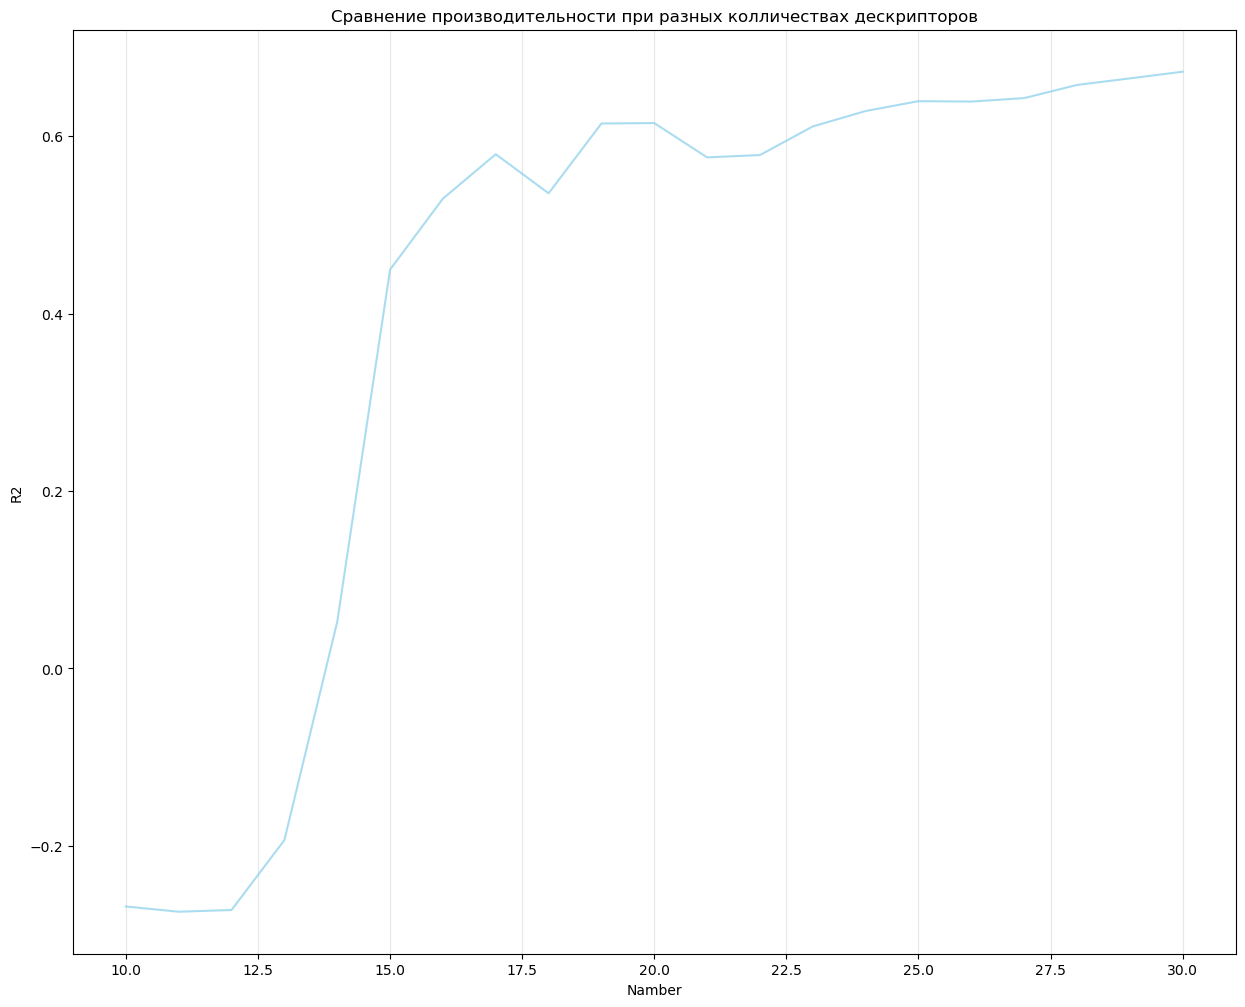

In [ ]:
# max_search(df_no_zeroB, features_b, "b")

0.7212570255305236

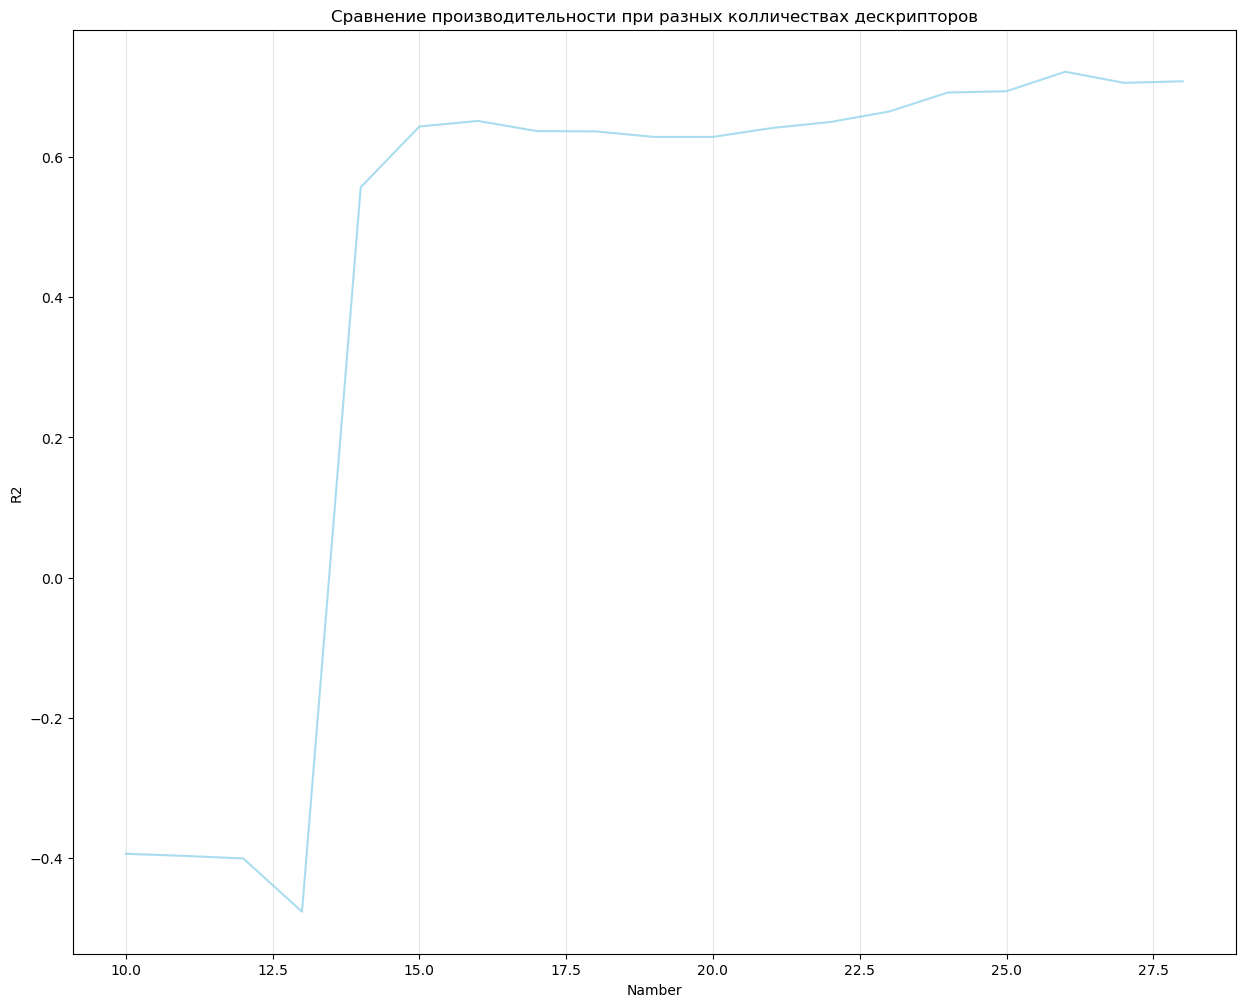

In [ ]:
# max_search(data, features_a, "a")

# Кастом фит на деревьях c нескучной фасовкой данных

In [32]:
def extra_trees_loo_analysis_castom(X, y, test_size=5, random_state=42, picture = False):
    """
    Полный анализ Extra Trees с Leave-One-Out и предсказаниями на новых данных
    """
    print("=" * 80)
    print("ПОЛНЫЙ АНАЛИЗ EXTRA TREES С LEAVE-ONE-OUT")
    print("=" * 80)
    
    # 1. Разделение данных на train и полностью новые данные
    X_train, X_new, y_train, y_new = train_test_split(
        X, y, test_size=test_size, random_state=random_state, shuffle=False
    )
    
    print(f"Размер тренировочных данных: {X_train.shape}")
    print(f"Размер новых данных (модель никогда не видела): {X_new.shape}")
    # print(f"Новые образцы для предсказания: {list(X_new.index)}")

    # Для финильной модели эти парамтеры показались мне наиболее оптимальными 
    et_model = ExtraTreesRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features=0.6,
        bootstrap=False,
        random_state=42,
        n_jobs=-1
    )
    
    # 3. Leave-One-Out кросс-валидация на тренировочных данных
    print("\n" + "=" * 50)
    print("LEAVE-ONE-OUT КРОСС-ВАЛИДАЦИЯ")
    print("=" * 50)
    
    loo = LeaveOneOut()
    loo_scores = []
    loo_predictions = []
    loo_true_values = []
    
    for train_idx, test_idx in loo.split(X_train):
        # Разделение для текущего фолда
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]
        
        # Обучение и предсказание
        et_model.fit(X_train_fold, y_train_fold)
        y_pred_fold = et_model.predict(X_test_fold)
        
        # Сохранение результатов
        mse_fold = mean_squared_error(y_test_fold, y_pred_fold)
        loo_scores.append(-mse_fold)  # neg MSE для консистентности
        loo_predictions.extend(y_pred_fold)
        loo_true_values.extend(y_test_fold)
    
    # 4. Финальное обучение на всех тренировочных данных
    print("\n" + "=" * 50)
    print("ФИНАЛЬНОЕ ОБУЧЕНИЕ МОДЕЛИ")
    print("=" * 50)
    
    et_model.fit(X_train, y_train)
    
    # 6. Предсказания на совершенно новых данных
    y_new_pred = et_model.predict(X_new)
    original_y_new_pred = y_new_pred.copy() # предсказали для hold out

    # Теперь положим неизвестные ранее даныне обратно в модель чтобы не терять точность на LOOCV

    # Для финильной модели эти парамтеры показались мне наиболее оптимальными 
    et_model_all = ExtraTreesRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features=0.6,
        bootstrap=False,
        random_state=42,
        n_jobs=-1
    )
    # 2. Объедините все данные для LOOCV
    X_all = pd.concat([X_train, X_new])
    y_all = pd.concat([y_train, y_new])

    # 3. Сделайте LOOCV на ВСЕХ данных
    loo_all = LeaveOneOut()
    loo_scores_all = []
    loo_predictions_all = []
    loo_true_values_all = []

    for train_idx, test_idx in loo_all.split(X_all):
        X_train_fold, X_test_fold = X_all.iloc[train_idx], X_all.iloc[test_idx]
        y_train_fold, y_test_fold = y_all.iloc[train_idx], y_all.iloc[test_idx]
        
        et_model_all.fit(X_train_fold, y_train_fold)
        y_pred_fold = et_model_all.predict(X_test_fold)
        
        mse_fold = mean_squared_error(y_test_fold, y_pred_fold)
        loo_scores_all.append(-mse_fold)
        loo_predictions_all.extend(y_pred_fold)
        loo_true_values_all.extend(y_test_fold)

    from sklearn.base import clone

    et_model_loo = clone(et_model_all) # Делаем копию модели на LOOCV 
    et_model_all.fit(X_all, y_all) # Доучиваемся целиком 

    y_train_pred = et_model_all.predict(X_all) # Финальные предсказания 

    # 7. Вычисление метрик
    # На тренировочных данных
    train_r2 = r2_score(y_all, y_train_pred)
    train_mse = mean_squared_error(y_all, y_train_pred)
    train_mae = mean_absolute_error(y_all, y_train_pred)
    
    # LOO результаты, они полученны в результате самой кросс валидации 
    loo_r2 = r2_score(loo_true_values_all, loo_predictions_all)
    loo_mse = mean_squared_error(loo_true_values_all, loo_predictions_all)
    loo_mae = mean_absolute_error(loo_true_values_all, loo_predictions_all)
    
    # На новых данных
    new_r2 = r2_score(y_new, original_y_new_pred)
    new_mse = mean_squared_error(y_new, original_y_new_pred)
    new_mae = mean_absolute_error(y_new, original_y_new_pred)
    
    # 8. Вывод результатов
    print("\n📊 РЕЗУЛЬТАТЫ:")
    print("Метрики на тренировочных данных:")
    print(f"  R²: {train_r2:.4f}, MSE: {train_mse:.4f}, MAE: {train_mae:.4f}")
    
    print("\nМетрики Leave-One-Out:")
    print(f"  R²: {loo_r2:.4f}, MSE: {loo_mse:.4f}, MAE: {loo_mae:.4f}")
    print(f"  LOO Score (mean neg_MSE): {np.mean(loo_scores_all):.4f} ± {np.std(loo_scores_all):.4f}")
    
    print("\nМетрики на НОВЫХ данных (модель никогда не видела):")
    print(f"  R²: {new_r2:.4f}, MSE: {new_mse:.4f}, MAE: {new_mae:.4f}")
    
    if picture == True:
        # 9. Визуализация
        plot_comprehensive_analysis(
            y_all, y_train_pred, 
            loo_true_values_all, loo_predictions_all,
            y_new, original_y_new_pred,
            X_new.index
        )
        
        # 10. Детальная информация о новых предсказаниях
        print_new_predictions_details(X_new, y_new, y_new_pred, X_new.index)
    return {
            'model': et_model_all,
            'LOOCV model': et_model_loo,
            'X_train': X_all,
            'y_train': y_all,
            'X_new': X_new,
            'y_new': y_new,
            'y_new_pred': y_new_pred,
            'loo_scores': loo_scores_all,
            'loo_predictions': loo_predictions_all,
            'loo_true_values': loo_true_values_all,
            'AE_LOOCV': np.abs((np.array(loo_true_values_all) - np.array(loo_predictions_all))),
            'AE_last': np.abs((np.array(y_all) - np.array(y_train_pred))),
            'metrics': {
                'train': {'r2': train_r2, 'mse': train_mse, 'mae': train_mae},
                'loo': {'r2': loo_r2, 'mse': loo_mse, 'mae': loo_mae},
                'new': {'r2': new_r2, 'mse': new_mse, 'mae': new_mae}
            }
    }
        
def plot_comprehensive_analysis(y_train, y_train_pred, loo_true, loo_pred, y_new, y_new_pred, new_indices):
    """
    Комплексная визуализация результатов
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Comprehensive analysis of pretiction \n for "A" using features selected for "B"', fontsize=16, fontweight='bold')
    
    # 1. Parity Plot - тренировочные данные
    axes[0, 0].scatter(y_train, y_train_pred, alpha=0.6, color='blue', s=50)
    # for i, idx in enumerate(y_train):
    #     axes[0, 0].annotate(f'{i}', (y_train[i], y_train_pred[i]), 
    #                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    min_val = min(y_train.min(), y_train_pred.min())
    max_val = max(y_train.max(), y_train_pred.max())
    axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    axes[0, 0].set_xlabel('True Values')
    axes[0, 0].set_ylabel('Predicted Values')
    axes[0, 0].set_title('Parity Plot: predictions for training on all data after LOOCV')
    axes[0, 0].grid(True, alpha=0.3)
    r2_train = r2_score(y_train, y_train_pred)
    axes[0, 0].text(0.05, 0.95, f'R² = {r2_train:.3f}', transform=axes[0, 0].transAxes,
                   bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    
    # 2. Parity Plot - LOO
    axes[0, 1].scatter(loo_true, loo_pred, alpha=0.6, color='green', s=50)
    # for i, idx in enumerate(loo_true):
    #     axes[0, 1].annotate(f'{i}', (loo_true[i], loo_pred[i]), 
    #                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    min_val_loo = min(min(loo_true), min(loo_pred))
    max_val_loo = max(max(loo_true), max(loo_pred))
    axes[0, 1].plot([min_val_loo, max_val_loo], [min_val_loo, max_val_loo], 'r--', linewidth=2)
    axes[0, 1].set_xlabel('True Values')
    axes[0, 1].set_ylabel('Predicted Values')
    axes[0, 1].set_title('Parity Plot: predictions for Leave-One-Out cross-validation (LOOCV)')
    axes[0, 1].grid(True, alpha=0.3)
    r2_loo = r2_score(loo_true, loo_pred)
    axes[0, 1].text(0.05, 0.95, f'R² = {r2_loo:.3f}', transform=axes[0, 1].transAxes,
                   bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    
    # 3. Parity Plot - Новые данные
    axes[0, 2].scatter(y_new, y_new_pred, alpha=0.6, color='red', s=80, edgecolors='black')
    # for i, idx in enumerate(new_indices):
    #     axes[0, 2].annotate(f'{idx}', (y_new.iloc[i], y_new_pred[i]), 
    #                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    min_val_new = min(min(y_new), min(y_new_pred))
    max_val_new = max(max(y_new), max(y_new_pred))
    axes[0, 2].plot([min_val_new, max_val_new], [min_val_new, max_val_new], 'r--', linewidth=2)
    axes[0, 2].set_xlabel('True Values')
    axes[0, 2].set_ylabel('Predicted Values')
    axes[0, 2].set_title('Parity Plot: predictions for hold out sample')
    axes[0, 2].grid(True, alpha=0.3)
    r2_new = r2_score(y_new, y_new_pred)
    axes[0, 2].text(0.05, 0.95, f'R² = {r2_new:.3f}', transform=axes[0, 2].transAxes,
                   bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    
    # 4. Распределение остатков - Train
    residuals_train = y_train - y_train_pred
    axes[1, 0].hist(residuals_train, bins=15, alpha=0.7, color='blue', edgecolor='black')
    axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_xlabel('Residuals')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of prediction errors \n in training on all data after LOOCV')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].text(0.05, 0.95, f'Mean value: {residuals_train.mean():.3f}\nStandard deviation: {residuals_train.std():.3f}', 
                   transform=axes[1, 0].transAxes, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    
    # 5. Распределение остатков - LOO
    residuals_loo = np.array(loo_true) - np.array(loo_pred)
    axes[1, 1].hist(residuals_loo, bins=15, alpha=0.7, color='green', edgecolor='black')
    axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_xlabel('Residuals')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Residuals distribution errors for \n Leave-One-Out cross-validation (LOOCV)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].text(0.05, 0.95, f'Mean value: {residuals_loo.mean():.3f}\nStandard deviation: {residuals_loo.std():.3f}', 
                   transform=axes[1, 1].transAxes, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    
    # 6. Распределение остатков - Новые данные
    residuals_new = y_new - y_new_pred
    axes[1, 2].hist(residuals_new, bins=min(10, len(y_new)), alpha=0.7, color='red', edgecolor='black')
    axes[1, 2].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1, 2].set_xlabel('Residuals')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].set_title('Residuals Distribution errors for hold out sample')
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 2].text(0.05, 0.95, f'Mean value: {residuals_new.mean():.3f}\nStandard deviation: {residuals_new.std():.3f}', 
                   transform=axes[1, 2].transAxes, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    
    plt.tight_layout()
    plt.show()

def print_new_predictions_details(X_new, y_new, y_new_pred, indices):
    """
    Детальная информация о предсказаниях на новых данных
    """
    print("\n" + "=" * 80)
    print("ДЕТАЛЬНАЯ ИНФОРМАЦИЯ О ПРЕДСКАЗАНИЯХ НА НОВЫХ ДАННЫХ")
    print("=" * 80)
    
    predictions_df = pd.DataFrame({
        'Образец': indices,
        'Истинное значение': y_new.values,
        'Предсказанное значение': y_new_pred,
        'Ошибка': y_new.values - y_new_pred,
        'Абсолютная ошибка': np.abs(y_new.values - y_new_pred),
        'Относительная ошибка (%)': np.abs((y_new.values - y_new_pred) / y_new.values) * 100
    })
    
    print(predictions_df.round(4))
    
    print(f"\n📈 СТАТИСТИКА ОШИБОК НА НОВЫХ ДАННЫХ:")
    print(f"  Средняя абсолютная ошибка: {predictions_df['Абсолютная ошибка'].mean():.4f}")
    print(f"  Максимальная абсолютная ошибка: {predictions_df['Абсолютная ошибка'].max():.4f}")
    print(f"  Средняя относительная ошибка: {predictions_df['Относительная ошибка (%)'].mean():.2f}%")
    print(f"  Стандартное отклонение ошибок: {predictions_df['Ошибка'].std():.4f}")


Запуск комплексного анализа Extra Trees...
ПОЛНЫЙ АНАЛИЗ EXTRA TREES С LEAVE-ONE-OUT
Размер тренировочных данных: (43, 20)
Размер новых данных (модель никогда не видела): (10, 20)

LEAVE-ONE-OUT КРОСС-ВАЛИДАЦИЯ

ФИНАЛЬНОЕ ОБУЧЕНИЕ МОДЕЛИ

📊 РЕЗУЛЬТАТЫ:
Метрики на тренировочных данных:
  R²: 0.9615, MSE: 22.9019, MAE: 3.5724

Метрики Leave-One-Out:
  R²: 0.6605, MSE: 201.9441, MAE: 11.2602
  LOO Score (mean neg_MSE): -201.9441 ± 287.5360

Метрики на НОВЫХ данных (модель никогда не видела):
  R²: 0.6872, MSE: 131.3975, MAE: 9.2656


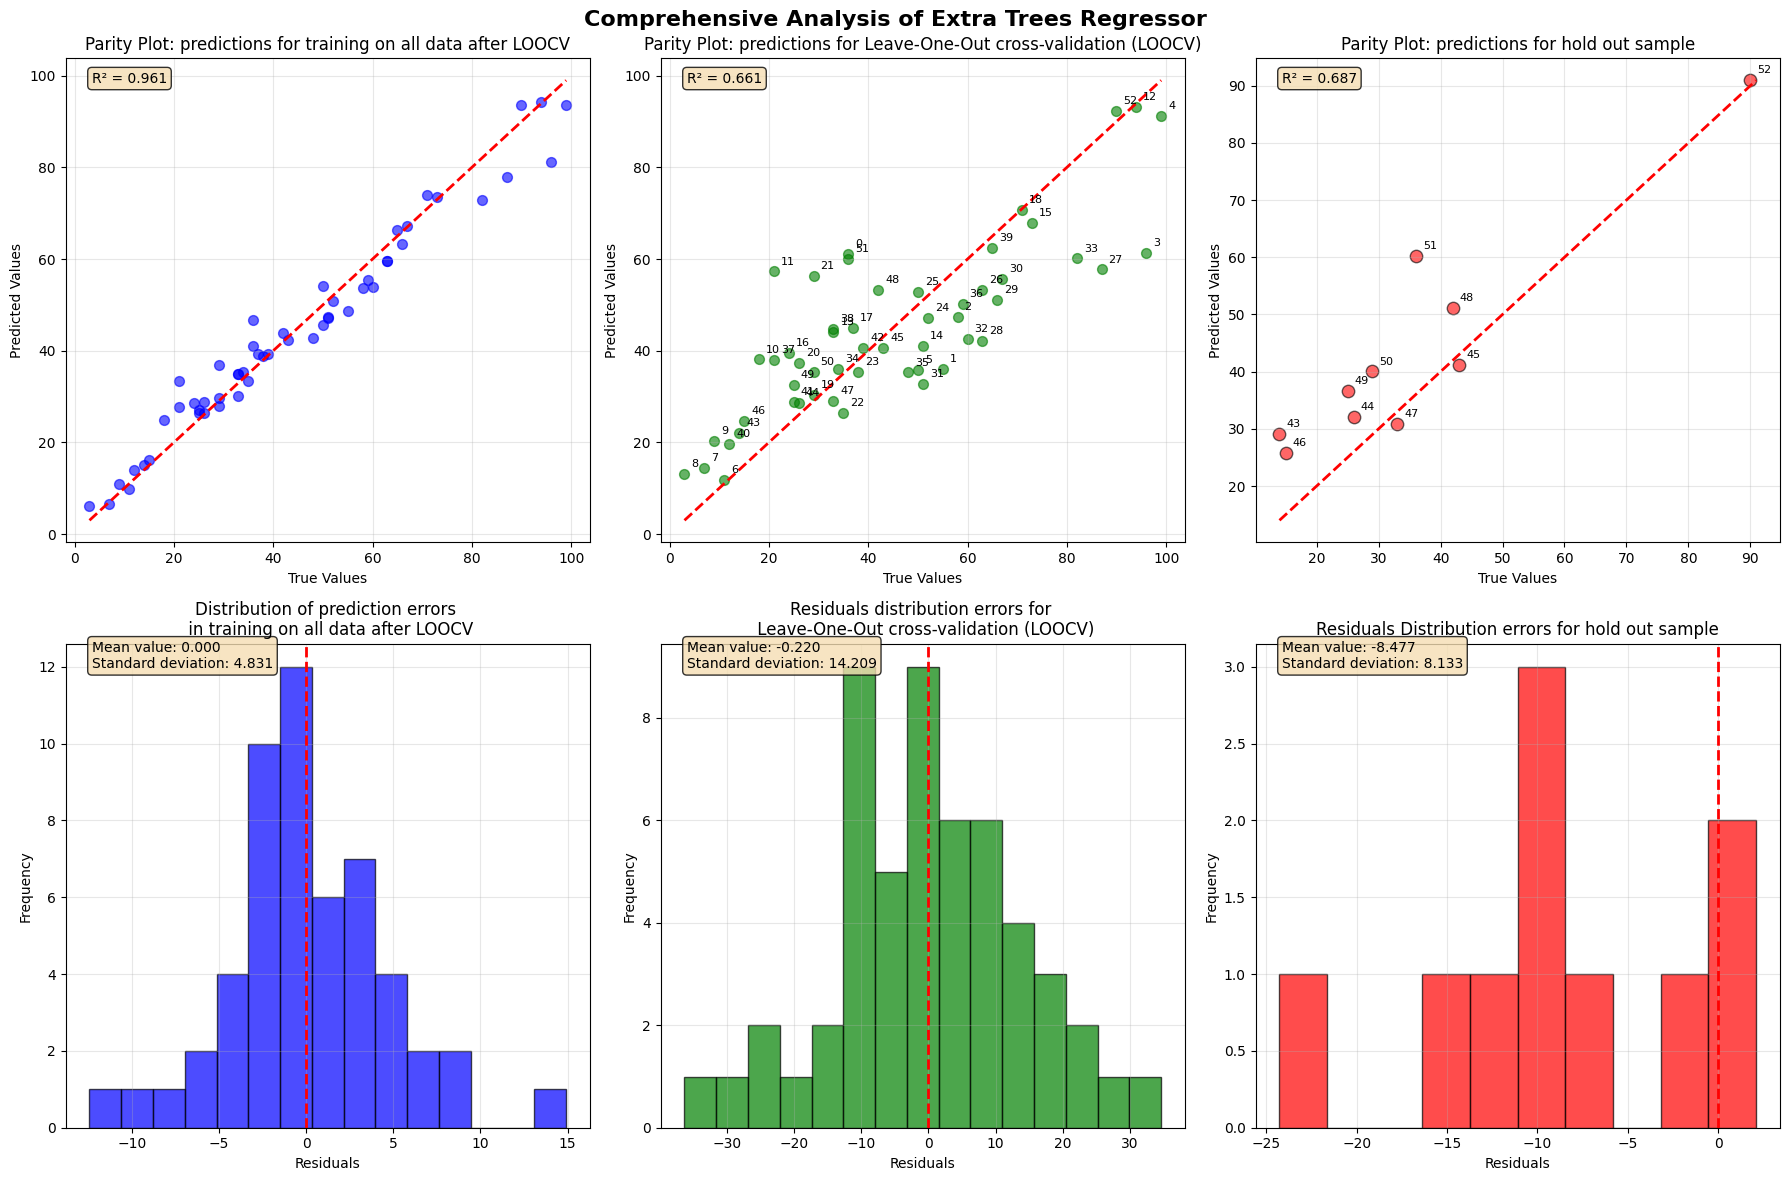


ДЕТАЛЬНАЯ ИНФОРМАЦИЯ О ПРЕДСКАЗАНИЯХ НА НОВЫХ ДАННЫХ
   Образец  Истинное значение  Предсказанное значение   Ошибка  \
0       43                 14                 29.0647 -15.0647   
1       44                 26                 32.0503  -6.0503   
2       45                 43                 41.1514   1.8486   
3       46                 15                 25.7103 -10.7103   
4       47                 33                 30.9072   2.0928   
5       48                 42                 51.0592  -9.0592   
6       49                 25                 36.5974 -11.5974   
7       50                 29                 40.0292 -11.0292   
8       51                 36                 60.2657 -24.2657   
9       52                 90                 90.9383  -0.9383   

   Абсолютная ошибка  Относительная ошибка (%)  
0            15.0647                  107.6052  
1             6.0503                   23.2703  
2             1.8486                    4.2991  
3            10.7103   

In [ ]:
# ЗАПУСК АНАЛИЗА ДЛЯ В
print("Запуск комплексного анализа Extra Trees...")
results_b = extra_trees_loo_analysis_castom(df_no_zeroB[features_b[:25]], df_no_zeroB["b"], test_size=10, random_state=42, picture=True)

Запуск комплексного анализа Extra Trees...
ПОЛНЫЙ АНАЛИЗ EXTRA TREES С LEAVE-ONE-OUT
Размер тренировочных данных: (59, 26)
Размер новых данных (модель никогда не видела): (10, 26)

LEAVE-ONE-OUT КРОСС-ВАЛИДАЦИЯ

ФИНАЛЬНОЕ ОБУЧЕНИЕ МОДЕЛИ

📊 РЕЗУЛЬТАТЫ:
Метрики на тренировочных данных:
  R²: 0.9708, MSE: 23.4408, MAE: 3.5167

Метрики Leave-One-Out:
  R²: 0.7213, MSE: 223.7585, MAE: 11.8119
  LOO Score (mean neg_MSE): -223.7585 ± 316.2371

Метрики на НОВЫХ данных (модель никогда не видела):
  R²: 0.7104, MSE: 205.2225, MAE: 12.3750


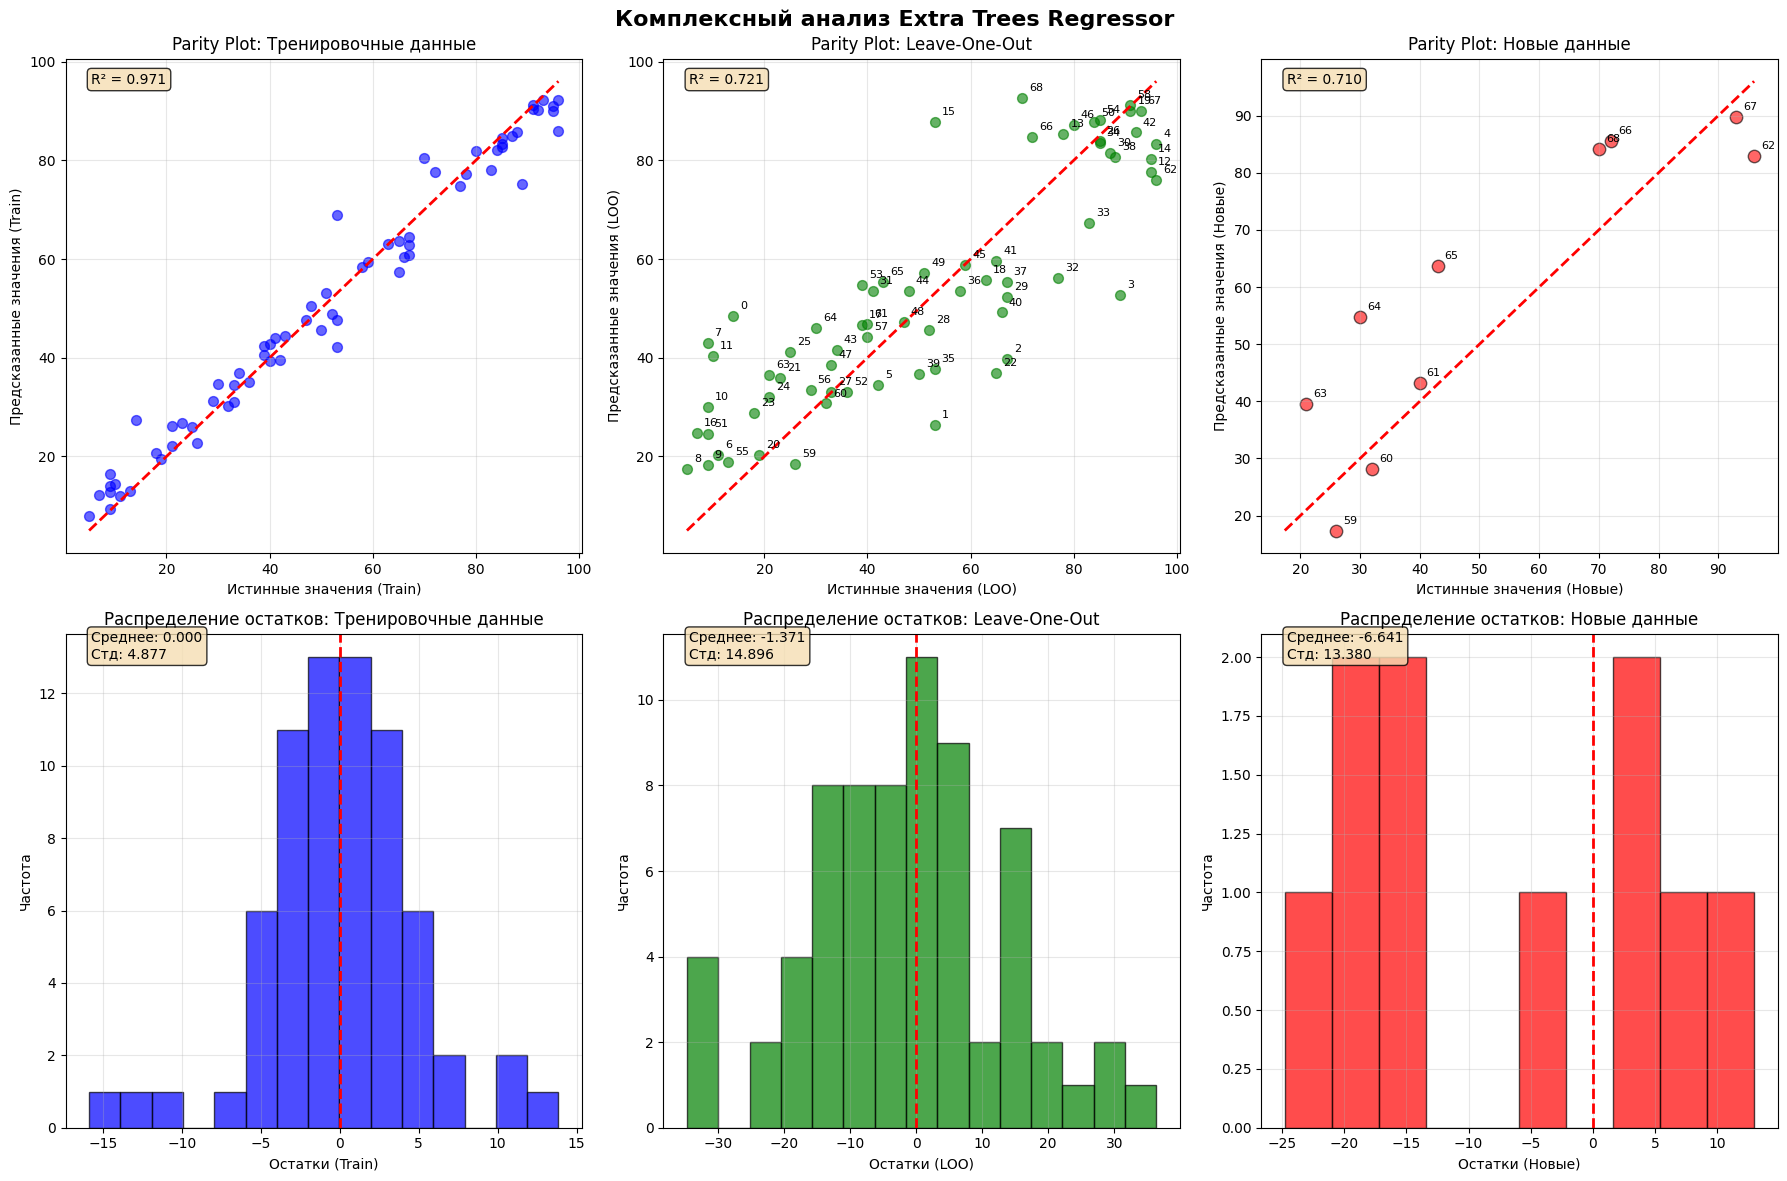


ДЕТАЛЬНАЯ ИНФОРМАЦИЯ О ПРЕДСКАЗАНИЯХ НА НОВЫХ ДАННЫХ
   Образец  Истинное значение  Предсказанное значение   Ошибка  \
0       59                 26                 17.3958   8.6042   
1       60                 32                 28.1950   3.8050   
2       61                 40                 43.2194  -3.2194   
3       62                 96                 83.0144  12.9856   
4       63                 21                 39.4900 -18.4900   
5       64                 30                 54.7973 -24.7973   
6       65                 43                 63.7056 -20.7056   
7       66                 72                 85.6306 -13.6306   
8       67                 93                 89.7248   3.2752   
9       68                 70                 84.2372 -14.2372   

   Абсолютная ошибка  Относительная ошибка (%)  
0             8.6042                   33.0929  
1             3.8050                   11.8906  
2             3.2194                    8.0486  
3            12.9856   

In [22]:
# ЗАПУСК АНАЛИЗА ДЛЯ А
print("Запуск комплексного анализа Extra Trees...")
results_a = extra_trees_loo_analysis_castom(data[features_a[:26]], data["a"], test_size=10, random_state=42, picture=True)

# Ревёрс фичей и таргетов

Запуск комплексного анализа Extra Trees...
ПОЛНЫЙ АНАЛИЗ EXTRA TREES С LEAVE-ONE-OUT
Размер тренировочных данных: (59, 25)
Размер новых данных (модель никогда не видела): (10, 25)

LEAVE-ONE-OUT КРОСС-ВАЛИДАЦИЯ

ФИНАЛЬНОЕ ОБУЧЕНИЕ МОДЕЛИ

📊 РЕЗУЛЬТАТЫ:
Метрики на тренировочных данных:
  R²: 0.9739, MSE: 20.9258, MAE: 3.4262

Метрики Leave-One-Out:
  R²: 0.7134, MSE: 230.0625, MAE: 11.6845
  LOO Score (mean neg_MSE): -230.0625 ± 320.5500

Метрики на НОВЫХ данных (модель никогда не видела):
  R²: 0.8595, MSE: 99.5854, MAE: 8.3605


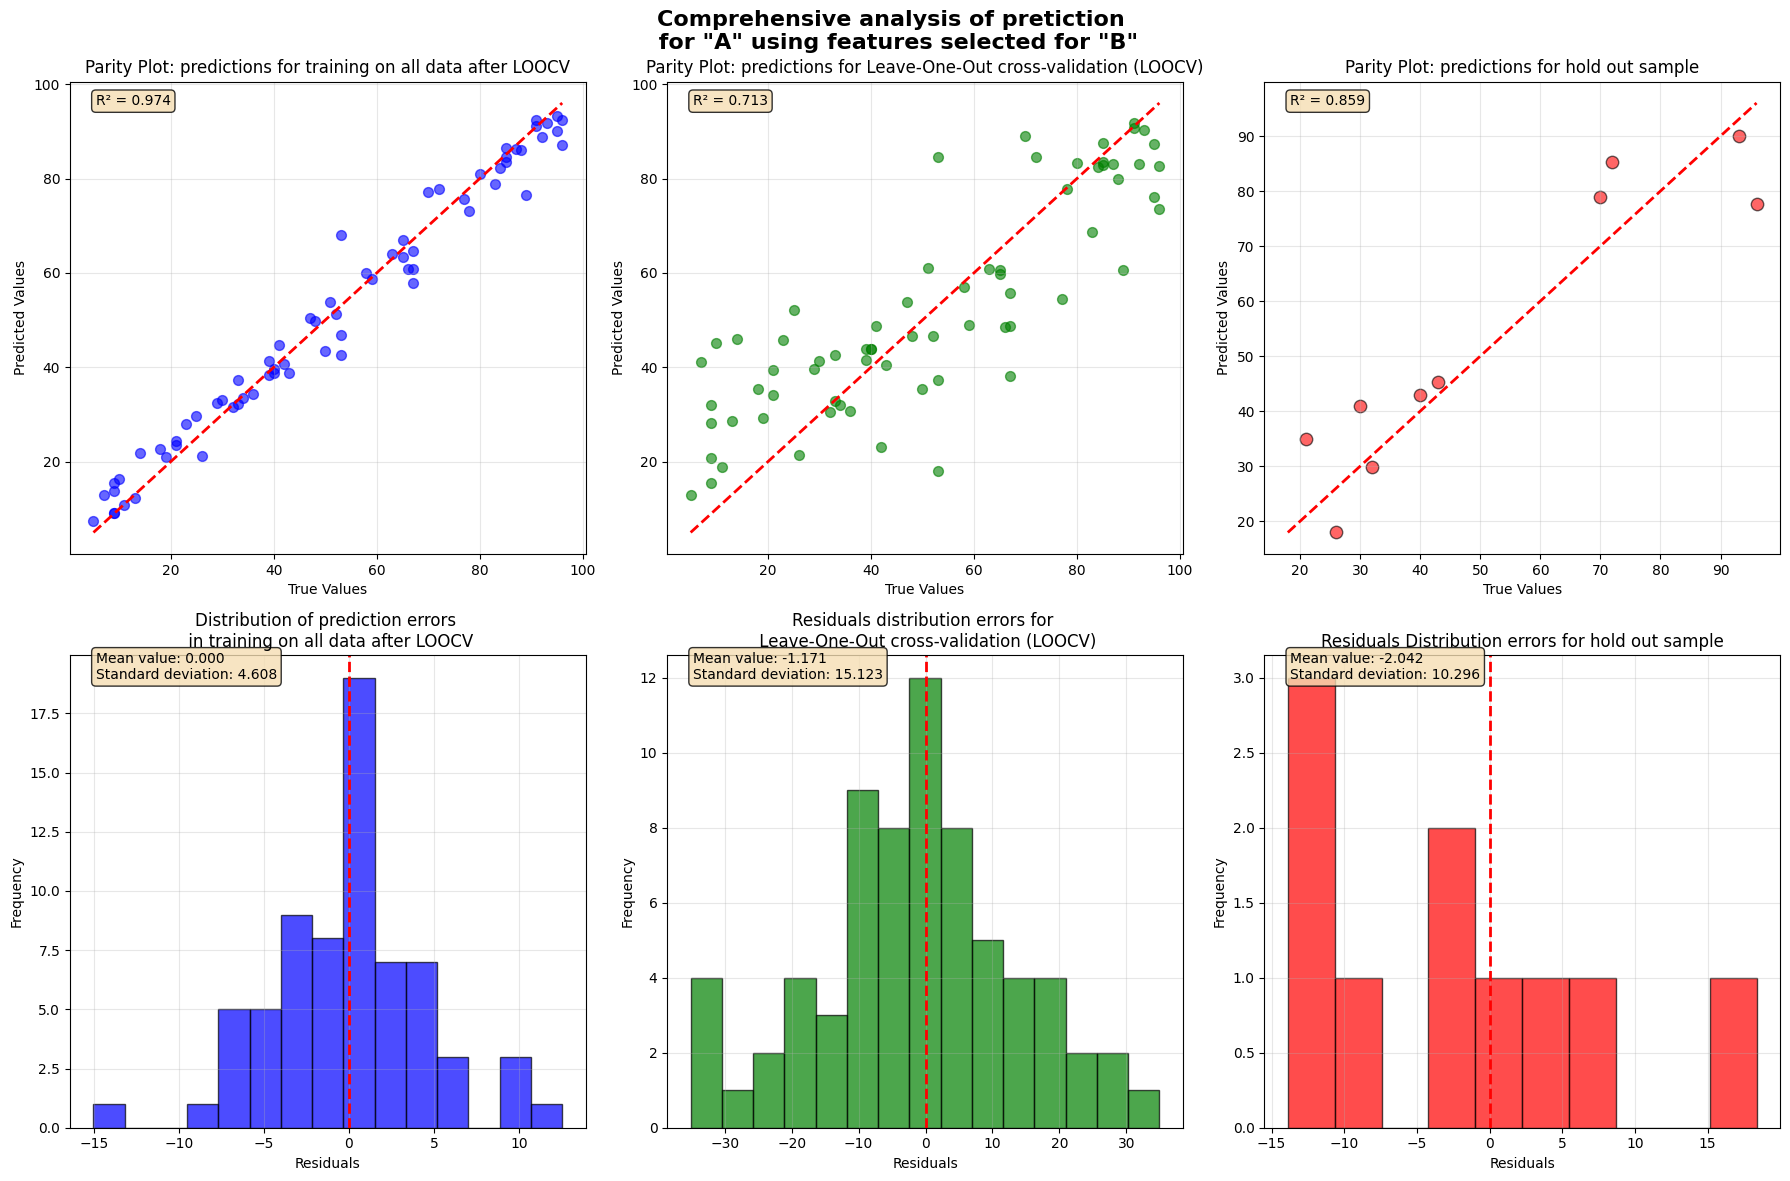


ДЕТАЛЬНАЯ ИНФОРМАЦИЯ О ПРЕДСКАЗАНИЯХ НА НОВЫХ ДАННЫХ
   Образец  Истинное значение  Предсказанное значение   Ошибка  \
0       59                 26                 17.9402   8.0598   
1       60                 32                 29.8507   2.1493   
2       61                 40                 42.8749  -2.8749   
3       62                 96                 77.6250  18.3750   
4       63                 21                 34.8789 -13.8789   
5       64                 30                 40.9071 -10.9071   
6       65                 43                 45.2058  -2.2058   
7       66                 72                 85.2675 -13.2675   
8       67                 93                 89.9928   3.0072   
9       68                 70                 78.8794  -8.8794   

   Абсолютная ошибка  Относительная ошибка (%)  
0             8.0598                   30.9994  
1             2.1493                    6.7165  
2             2.8749                    7.1872  
3            18.3750   

In [33]:
# ЗАПУСК АНАЛИЗА ДЛЯ В
print("Запуск комплексного анализа Extra Trees...")
resultsA_b = extra_trees_loo_analysis_castom(data[features_b[:25]], data["a"], test_size=10, random_state=42, picture=True)

In [29]:
# # ЗАПУСК АНАЛИЗА ДЛЯ В
# print("Запуск комплексного анализа Extra Trees...")
# resultsA_b = extra_trees_loo_analysis_castom(df_no_zeroB[features_a[:25]], df_no_zeroB["b"], test_size=10, random_state=42, picture=True)

In [24]:
results_b.keys()

dict_keys(['model', 'LOOCV model', 'X_train', 'y_train', 'X_new', 'y_new', 'y_new_pred', 'loo_scores', 'loo_predictions', 'loo_true_values', 'AE_LOOCV', 'AE_last', 'metrics'])

In [108]:
np.abs(np.array(df_no_zeroB["b"]) - np.array(results_b["loo_predictions"])) #- np.array(results_b["AE_LOOCV"])

array([14.63577778, 19.96277778, 11.08583333, 28.32111111, 10.66861111,
       12.24388889,  9.38555556, 11.73861111, 10.22611111, 13.0075    ,
       14.62455556, 25.94655556,  1.71555556, 16.4225    ,  4.94555556,
        0.86611111, 13.06861111,  5.1475    ,  3.53805556,  5.32722222,
       12.00505556, 29.80766667,  9.38777778,  0.19944444,  6.54805556,
        4.14861111,  7.01372222, 19.86555556, 20.15194444, 14.20944444,
        5.02944444, 17.94416667, 17.04861111, 15.737     ,  1.77816667,
       11.34111111, 15.71761111, 21.46277778, 15.7475    ,  2.61605556,
       10.75222222,  5.37361111,  5.12861111,  8.80972222,  8.80583333,
        7.17666667, 12.09416667,  3.26777778,  5.36388889,  7.68055556,
        4.69527778, 12.11722222,  3.85972222])

In [110]:
np.array(results_b["loo_predictions"])

array([50.63577778, 35.03722222, 46.91416667, 67.67888889, 88.33138889,
       37.75611111, 20.38555556, 18.73861111, 13.22611111, 22.0075    ,
       32.62455556, 46.94655556, 92.28444444, 49.4225    , 46.05444444,
       73.86611111, 37.06861111, 42.1475    , 74.53805556, 34.32722222,
       38.00505556, 58.80766667, 25.61222222, 38.19944444, 45.45194444,
       54.14861111, 55.98627778, 67.13444444, 42.84805556, 51.79055556,
       61.97055556, 33.05583333, 42.95138889, 66.263     , 35.77816667,
       36.65888889, 43.28238889, 42.46277778, 48.7475    , 62.38394444,
       22.75222222, 30.37361111, 44.12861111, 22.80972222, 34.80583333,
       50.17666667, 27.09416667, 29.73222222, 47.36388889, 32.68055556,
       33.69527778, 48.11722222, 86.14027778])

In [116]:
np.abs(np.array(data["a"]) - np.array(results_a["loo_true_values"])) 

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0])

# Сейв модели и фичей 

In [28]:
import joblib

In [26]:
results_a['model']

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,4
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,0.6
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [21]:
import os
os.getcwd()

'/mnt/e/Programing/JupyterLab/Chemistry/ChemDraw/code'

In [29]:
joblib.dump(results_b['model'], 'streamlit/model_b2.pkl')
joblib.dump(features_b[:25], 'streamlit/features_b2.pkl')

['streamlit/features_b2.pkl']

In [45]:
features_a[:26]

['reagent1_ATS2Z',
 'reagent1_ATS1m',
 'reagent1_ATS8m',
 'reagent1_AATSC0are',
 'reagent1_AATSC3i',
 'reagent1_GATS2d',
 'reagent1_GATS3m',
 'reagent1_GATS2i',
 'reagent1_SpMAD_Dzse',
 'reagent1_TASA',
 'reagent1_C2SP2',
 'reagent1_SlogP_VSA7',
 'reagent2_ATS8p',
 'reagent2_ATSC1se',
 'reagent2_MATS3v',
 'reagent2_MATS1se',
 'reagent2_SpAD_Dzse',
 'reagent2_Mse',
 'reagent2_SRW04',
 'product1_AATS3p',
 'product1_ATSC1d',
 'product1_ATSC7are',
 'product1_AATSC4m',
 'product1_AATSC8m',
 'product1_AATSC8p',
 'product1_MATS8p']

In [30]:
# Сохраняем модель, при том обученную 
joblib.dump(results_a['model'], 'streamlit/model_a2.pkl')
# Сохраняем массив фичей
joblib.dump(features_a[:26], 'streamlit/features_a2.pkl')

['streamlit/features_a2.pkl']

# Простой feature importanse для рисования 

### Важно понимать, что ген алгоритм выдал булевую маску по всему вектору фичей и НЕ упорядочил фичи по важности

In [32]:
# Если у уже есть обученная модель et_model
def get_feature_importance_simple(model, feature_names):
    """
    Быстрое получение важности признаков
    """
    importance = model.feature_importances_
    
    # Создаем DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    # Быстрая визуализация
    plt.figure(figsize=(10, 8))
    top_20 = importance_df.head(20)
    
    plt.barh(top_20['feature'], top_20['importance'], color='lightblue')
    plt.xlabel('Важность признака')
    plt.title('Топ-20 самых важных признаков')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("Топ-10 самых важных признаков:")
    print(top_20.head(10).to_string(index=False))
    
    return importance_df

In [33]:
features_a[:30]

['reagent1_ATS2Z',
 'reagent1_ATS1m',
 'reagent1_ATS8m',
 'reagent1_AATSC0are',
 'reagent1_AATSC3i',
 'reagent1_GATS2d',
 'reagent1_GATS3m',
 'reagent1_GATS2i',
 'reagent1_SpMAD_Dzse',
 'reagent1_TASA',
 'reagent1_C2SP2',
 'reagent1_SlogP_VSA7',
 'reagent2_ATS8p',
 'reagent2_ATSC1se',
 'reagent2_MATS3v',
 'reagent2_MATS1se',
 'reagent2_SpAD_Dzse',
 'reagent2_Mse',
 'reagent2_SRW04',
 'product1_AATS3p',
 'product1_ATSC1d',
 'product1_ATSC7are',
 'product1_AATSC4m',
 'product1_AATSC8m',
 'product1_AATSC8p',
 'product1_MATS8p']

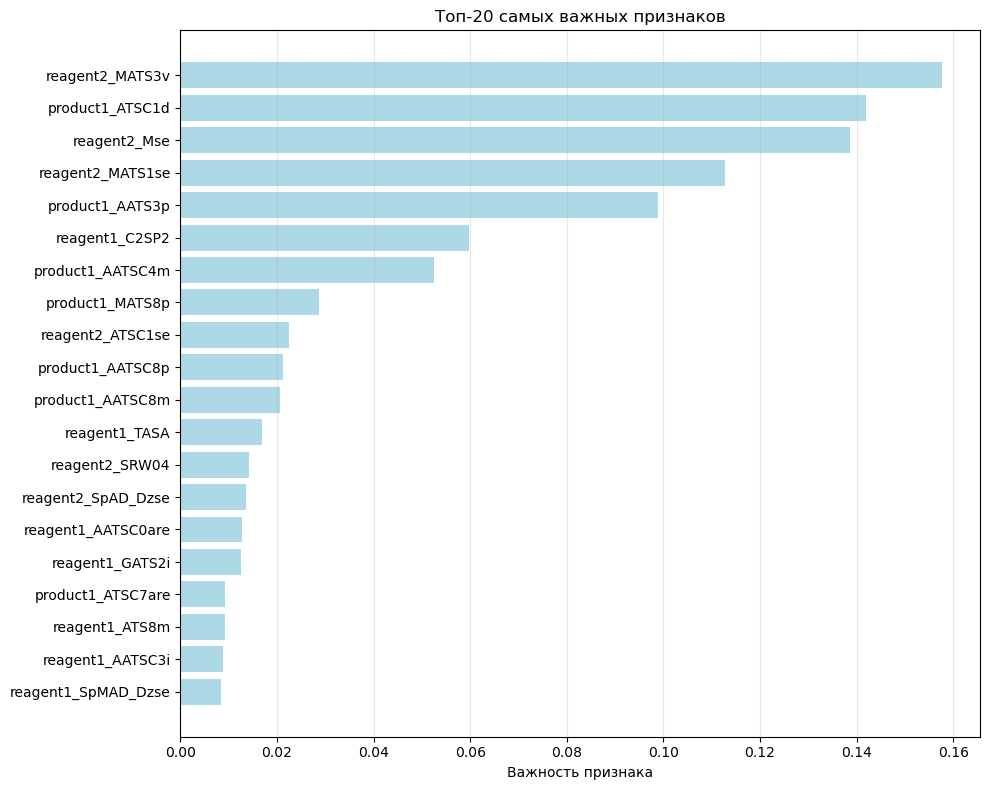

Топ-10 самых важных признаков:
         feature  importance
 reagent2_MATS3v    0.157649
 product1_ATSC1d    0.142010
    reagent2_Mse    0.138633
reagent2_MATS1se    0.112648
 product1_AATS3p    0.098937
  reagent1_C2SP2    0.059754
product1_AATSC4m    0.052441
 product1_MATS8p    0.028758
reagent2_ATSC1se    0.022403
product1_AATSC8p    0.021192


In [34]:
# Использование
importance_df = get_feature_importance_simple(results_a["model"], features_a[:26])

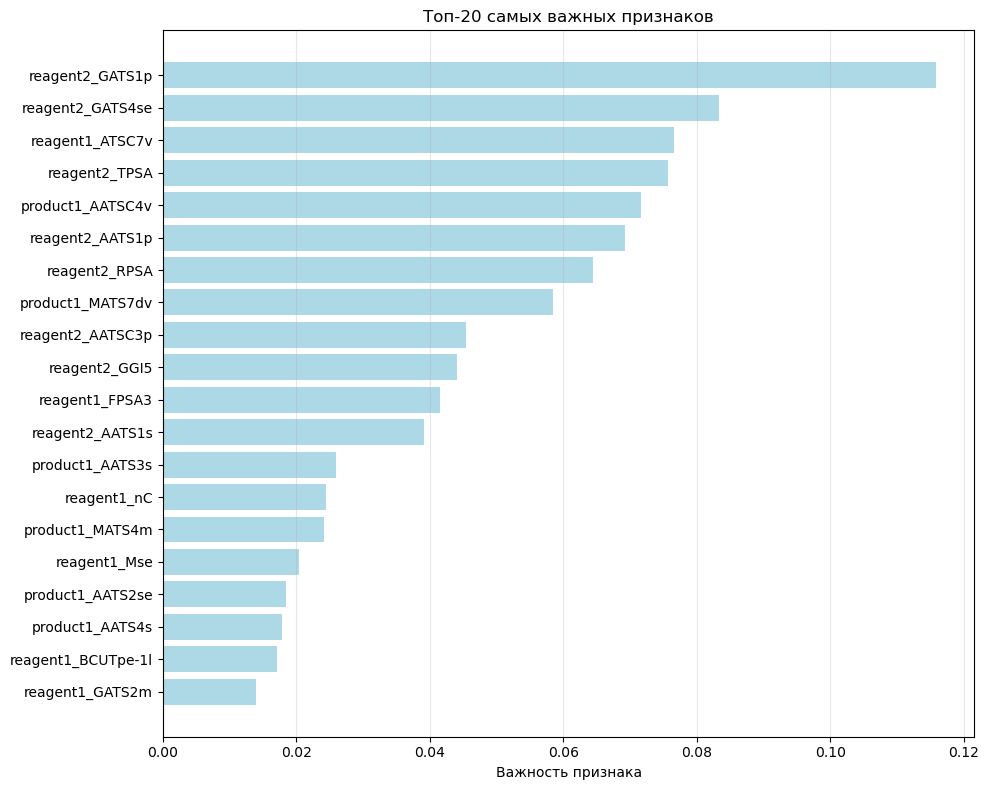

Топ-10 самых важных признаков:
         feature  importance
 reagent2_GATS1p    0.115771
reagent2_GATS4se    0.083346
 reagent1_ATSC7v    0.076631
   reagent2_TPSA    0.075643
product1_AATSC4v    0.071656
 reagent2_AATS1p    0.069234
   reagent2_RPSA    0.064472
product1_MATS7dv    0.058502
reagent2_AATSC3p    0.045428
   reagent2_GGI5    0.044071


In [37]:
# Использование
importance_df = get_feature_importance_simple(results_b["model"], features_b[:25])

# SHAP анализ 

In [36]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [25]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import ExtraTreesRegressor

In [156]:
def shap_analysis_extra_trees(model, X, y=None, data = None, sample_size=100, random_state=42, rows_to_annotate = None, threshold = 0):
    """
    SHAP анализ для Extra Trees регрессии
    """
    print("=" * 80)
    print("SHAP ANALYSIS FOR EXTRA TREES REGRESSION")
    print("=" * 80)
    
    # Выбор подвыборки для ускорения вычислений
    if len(X) > sample_size:
        X_sample = X.sample(n=sample_size, random_state=random_state)
        print(f"Using sample of {sample_size} instances for SHAP analysis")
    else:
        X_sample = X
        print(f"Using all {len(X)} instances for SHAP analysis")
    
    # Инициализация SHAP объяснителя для деревьев
    explainer = shap.TreeExplainer(model)
    
    # Вычисление SHAP значений
    print("Calculating SHAP values...")
    shap_values = explainer.shap_values(X_sample)
    
    # Обработка expected_value для регрессии
    expected_value = explainer.expected_value
    if isinstance(expected_value, np.ndarray):
        expected_value = expected_value[0] if len(expected_value) > 0 else expected_value
    # print(f"Base value (expected value): {expected_value:.4f}")
    print(f"SHAP values shape: {shap_values.shape}")
    
    # Создание Explanation объекта для совместимости
    shap_explanation = shap.Explanation(
        values=shap_values,
        base_values=expected_value,
        data=X_sample.values,
        feature_names=X_sample.columns.tolist()
    )
    
    # # 1. Summary plot (главный график)
    # print("\n📈 Creating summary plot...")
    # plt.figure(figsize=(12, 8))
    # shap.summary_plot(shap_values, X_sample, show=False)
    # plt.title("SHAP Summary Plot - Feature Importance", fontsize=16, fontweight='bold')
    # plt.tight_layout()
    # plt.show()

    print("\n📈 Creating summary plot with index annotations...")
    plt.figure(figsize=(12, 8))
    
    # Создаем базовый summary plot
    shap.summary_plot(shap_values, X_sample, show=False)
    
    # Добавляем аннотации индексов для точек, превышающих threshold
    shap_df = _add_simple_index_annotations(shap_values, X_sample, df = data, threshold=threshold, rows_to_annotate= rows_to_annotate)
    
    plt.title(f"SHAP Summary Plot - Feature Importance)", 
              fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 2. Bar plot (средние абсолютные SHAP значения)
    print("📊 Creating feature importance plot...")
    plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance (Mean |SHAP|)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 3. Beeswarm plot
    print("🐝 Creating beeswarm plot...")
    plt.figure(figsize=(12, 8))
    shap.plots.beeswarm(shap_explanation, show=False)
    plt.title("SHAP Beeswarm Plot - Feature Effects", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 4. Waterfall plot для первого наблюдения
    print("🌊 Creating waterfall plot for first instance...")
    plt.figure(figsize=(14, 8))
    shap.plots.waterfall(shap_explanation[0], show=False, max_display=15)
    plt.title(f"SHAP Waterfall Plot - Instance: {X_sample.index[0]}", 
              fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 5. Force plot для первого наблюдения
    print("⚡ Creating force plot...")
    plt.figure(figsize=(14, 4))
    shap.plots.force(shap_explanation[0], matplotlib=True, show=False)
    plt.title(f"SHAP Force Plot - Instance: {X_sample.index[0]}", 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 6. Decision plot для нескольких наблюдений
    print("📈 Creating decision plot...")
    plt.figure(figsize=(14, 10))
    shap.decision_plot(expected_value, shap_values[:10], 
                      X_sample.iloc[:10], 
                      feature_names=list(X_sample.columns),
                      show=False)
    plt.title("SHAP Decision Plot (First 10 Instances)", 
              fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 7. Dependence plots для топ-4 признаков
    print("📊 Creating dependence plots for top 4 features...")
    top_features = get_top_features_from_shap(shap_values, X_sample.columns, n=4)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()
    
    for i, feature in enumerate(top_features):
        shap.dependence_plot(feature, shap_values, X_sample, 
                           ax=axes[i], show=False)
        axes[i].set_title(f'SHAP Dependence: {feature}', fontweight='bold', fontsize=12)
        axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Вычисление и вывод важности признаков
    importance_df = get_shap_feature_importance(shap_values, X_sample.columns)
    
    # Возвращаем результаты
    results = {
        'explainer': explainer,
        'shap_values': shap_values,
        'expected_value': expected_value,
        'X_sample': X_sample,
        'feature_importance': importance_df,
        'shap_explanation': shap_explanation
    }
    
    return results, shap_df

def _add_simple_index_annotations(shap_values, X_sample, df = None, threshold=0, rows_to_annotate = None):
    """
    Версия с умным размещением по зонам и выводом данных
    """
    ax = plt.gca()
    # Получаем порядок признаков с графика
    y_tick_labels = [label.get_text() for label in ax.get_yticklabels()]
    feature_names = X_sample.columns.tolist()
    
    position_to_feature_idx = {}
    for position, feature_name in enumerate(y_tick_labels):
        if feature_name in feature_names and feature_name in rows_to_annotate:
            print(feature_name)
            position_to_feature_idx[position] = feature_names.index(feature_name)
    
    # Создаем зоны для размещения аннотаций
    annotation_zones = {}
    
    # Список для сбора информации о выбивающихся точках
    outlier_data = []
    
    for position, feature_idx in position_to_feature_idx.items():
        feature_name = feature_names[feature_idx]
        feature_shap = shap_values[:, feature_idx]
        high_impact_indices = np.where(np.abs(feature_shap) > threshold)[0]
        
        # Группируем точки по x-координатам для этого признака
        x_positions = []
        for idx in high_impact_indices:
            shap_val = feature_shap[idx]
            sample_index = X_sample.index[idx]
            feature_value = X_sample.iloc[idx, feature_idx]
            
            # Сохраняем данные для вывода
            outlier_data.append({
                'feature': feature_name,
                'feature_value': feature_value,
                'index': sample_index,
                'reaction_name': df["inp+inp=out"][sample_index],
                'shap_value': shap_val,
                'abs_shap': abs(shap_val)
            })
            
            x_positions.append((shap_val, sample_index, position))
        
        # Сортируем по x координате
        x_positions.sort(key=lambda x: x[0])
        
        # Размещаем аннотации с разными y-смещениями
        for i, (x, text, y_pos) in enumerate(x_positions):
            # Чередуем смещения: выше, ниже, выше, ниже...
            y_offset = 10 if i % 2 == 0 else -10
            x_offset = 5 + (i % 3) * 8  # Разные x-смещения
            
            ax.annotate(text,
                       xy=(x, y_pos),
                       xytext=(x_offset, y_offset),
                       textcoords='offset points',
                       fontsize=6,
                       alpha=0.7,
                       bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.5))
    
    # Выводим таблицу с данными
    _print_outlier_table_pandas(outlier_data, threshold)
    
    return outlier_data

# Альтернативный вариант с использованием pandas для более красивого вывода
def _print_outlier_table_pandas(outlier_data, threshold):
    """
    Выводит таблицу с использованием pandas для красивого форматирования
    """
    if not outlier_data:
        print(f"\n📊 Нет точек с |SHAP| > {threshold:.2f}")
        return
    
    import pandas as pd
    
    # Создаем DataFrame
    df = pd.DataFrame(outlier_data)
    df = df.sort_values('feature', ascending=False)

    # global aut_SHAP_b
    # aut_SHAP_b = df
    
    # # Переименовываем колонки для красивого вывода
    # df_display = df[['feature', 'shap_value', 'index', 'feature_value', 'abs_shap']].copy()
    # df_display.columns = ['Фича', 'SHAP значение', 'Индекс', 'Значение фичи', '|SHAP|']
    
    print(f"\n📊 ТОЧКИ С ВЫСОКИМ ВЛИЯНИЕМ (|SHAP| > {threshold:.2f})")
    print("=" * 80)
    
    # Настраиваем форматирование
    pd.set_option('display.max_rows', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 20)

    print(df.to_string(index=False, formatters={
        'SHAP значение': '{:>10.3f}'.format,
        'Значение фичи': '{:>10.3f}'.format,
        '|SHAP|': '{:>8.3f}'.format
    }))
    
    print(f"\nВсего точек: {len(df)}")
    print(f"Диапазон |SHAP|: {df['abs_shap'].min():.3f} - {df['abs_shap'].max():.3f}")
    

def _print_outlier_table(outlier_data, threshold):
    """
    Выводит красивую таблицу с информацией о выбивающихся точках
    """
    if not outlier_data:
        print(f"\n📊 Нет точек с |SHAP| > {threshold:.2f}")
        return
    
    print(f"\n📊 ТОЧКИ С ВЫСОКИМ ВЛИЯНИЕМ (|SHAP| > {threshold:.2f})")
    print("=" * 85)
    
    # Сортируем по абсолютному значению SHAP (по убыванию)
    outlier_data.sort(key=lambda x: x['abs_shap'], reverse=True)
    
    # Выводим заголовок таблицы
    print(f"{'Фича':<25} {'SHAP значение':<15} {'Индекс':<12} {'Значение фичи':<15} {'|SHAP|':<10}")
    print("-" * 85)
    
    # Выводим данные
    for data in outlier_data:
        print(f"{data['feature']:<25} {data['shap_value']:>12.3f}  {data['index']:<12} {data['feature_value']:>12.3f}  {data['abs_shap']:>8.3f}")
    
    print("-" * 85)
    print(f"Всего точек: {len(outlier_data)}")
    
    # Дополнительная статистика
    if outlier_data:
        max_shap = max(outlier_data, key=lambda x: x['abs_shap'])
        min_shap = min(outlier_data, key=lambda x: x['abs_shap'])
        print(f"Максимальное |SHAP|: {max_shap['abs_shap']:.3f} (фича: {max_shap['feature']}, индекс: {max_shap['index']})")
        print(f"Минимальное |SHAP|: {min_shap['abs_shap']:.3f} (фича: {min_shap['feature']}, индекс: {min_shap['index']})")
        
def get_shap_feature_importance(shap_values, feature_names):
    """
    Вычисление важности признаков на основе SHAP
    """
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'shap_importance': np.abs(shap_values).mean(axis=0),
        'shap_std': np.abs(shap_values).std(axis=0)
    }).sort_values('shap_importance', ascending=False)
    
    print("\n🎯 Top 15 Features by SHAP Importance:")
    print(importance_df.head(15).to_string(index=False, float_format='%.4f'))
    
    return importance_df

def get_top_features_from_shap(shap_values, feature_names, n=10):
    """
    Получить топ-N самых важных признаков по SHAP
    """
    importance = np.abs(shap_values).mean(axis=0)
    top_indices = np.argsort(importance)[::-1][:n]
    return [feature_names[i] for i in top_indices]

In [146]:
results_a.keys()

dict_keys(['model', 'LOOCV model', 'X_train', 'y_train', 'X_new', 'y_new', 'y_new_pred', 'loo_scores', 'loo_predictions', 'loo_true_values', 'AE_LOOCV', 'AE_last', 'metrics'])

SHAP ANALYSIS FOR EXTRA TREES REGRESSION
Using all 53 instances for SHAP analysis
Calculating SHAP values...
SHAP values shape: (53, 25)

📈 Creating summary plot with index annotations...
reagent2_RPSA
reagent2_TPSA
reagent2_AATSC3p
reagent2_AATS1p
reagent2_GATS1p

📊 ТОЧКИ С ВЫСОКИМ ВЛИЯНИЕМ (|SHAP| > 5.00)
         feature  feature_value  index reaction_name  shap_value  abs_shap
   reagent2_TPSA      16.285973      6     1a+2h=3ah   -9.045376  9.045376
   reagent2_TPSA      19.896608      7     1a+2i=3ai   -9.488354  9.488354
   reagent2_TPSA      21.400154      8     1a+2j=3aj   -9.813269  9.813269
   reagent2_TPSA      15.524783      9     1a+2k=3ak   -9.309887  9.309887
   reagent2_RPSA       0.034676      6     1a+2h=3ah   -6.088509  6.088509
   reagent2_RPSA       0.039696      8     1a+2j=3aj   -6.483443  6.483443
   reagent2_RPSA       0.038014      9     1a+2k=3ak   -6.294329  6.294329
   reagent2_RPSA       0.024474      7     1a+2i=3ai   -5.734937  5.734937
 reagent2_GATS1p

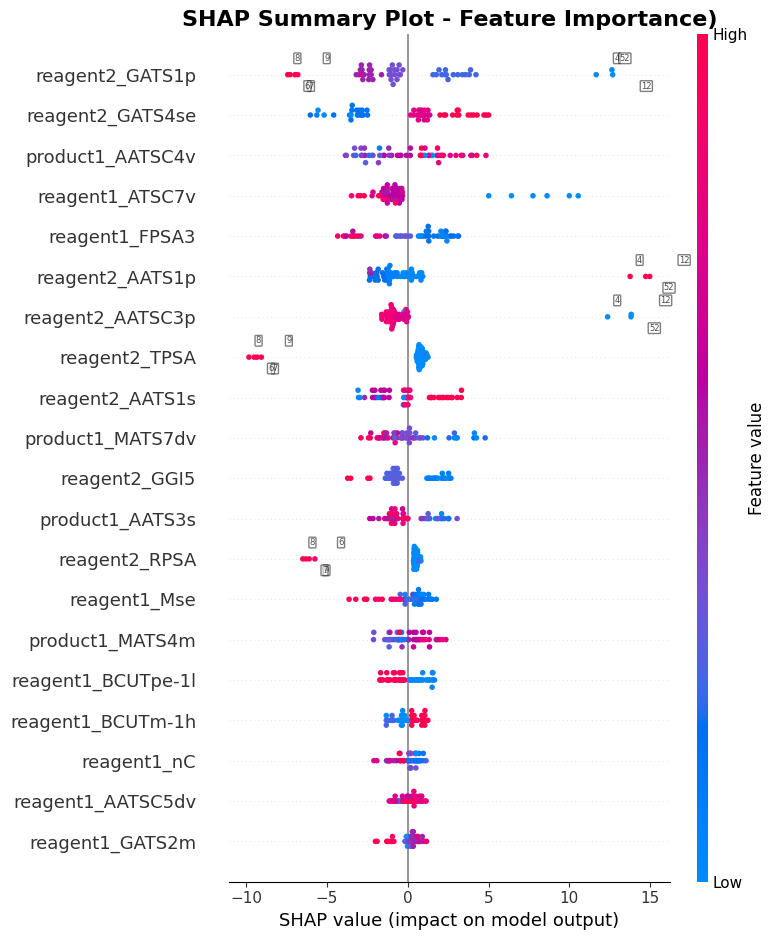

📊 Creating feature importance plot...


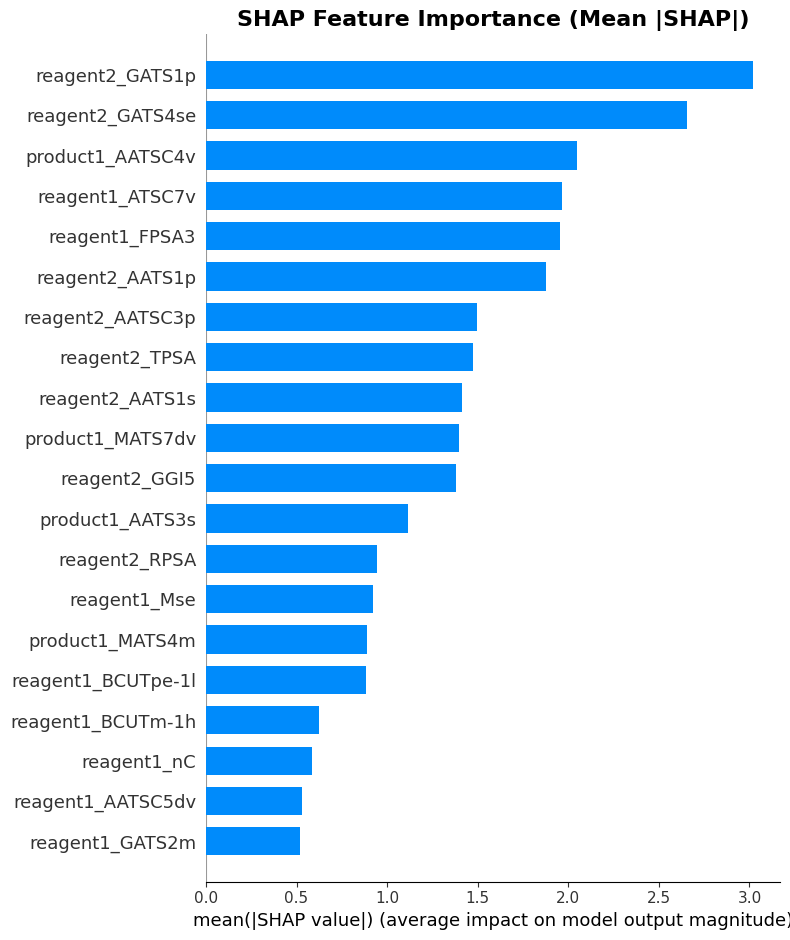

🐝 Creating beeswarm plot...


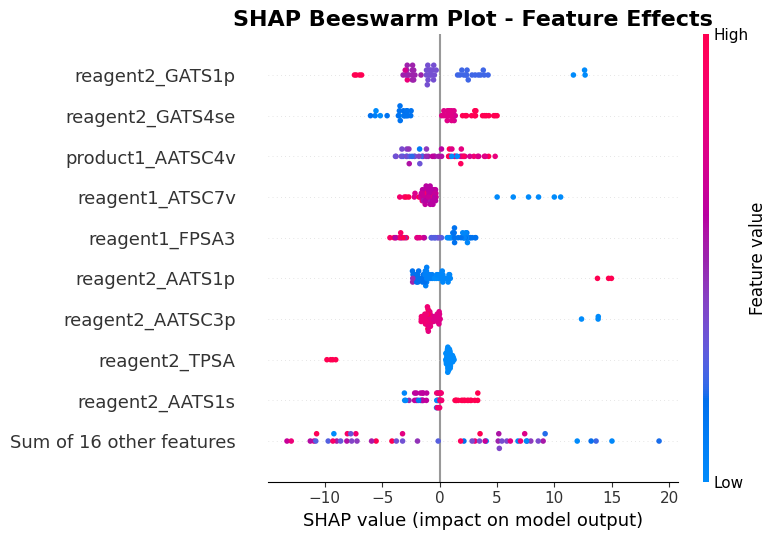

🌊 Creating waterfall plot for first instance...


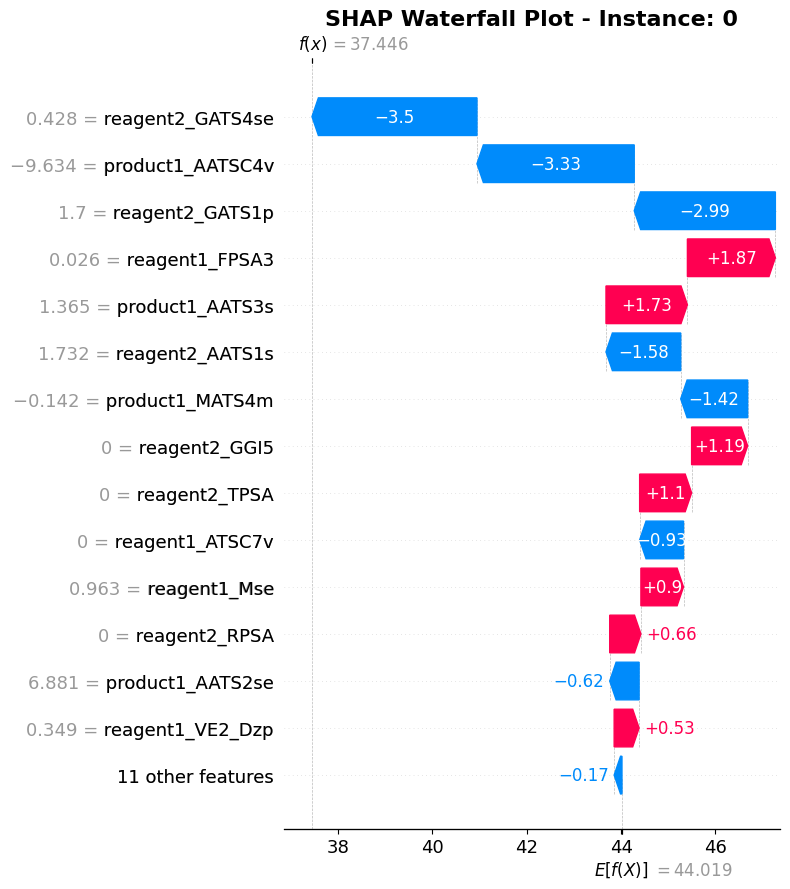

⚡ Creating force plot...


<Figure size 1400x400 with 0 Axes>

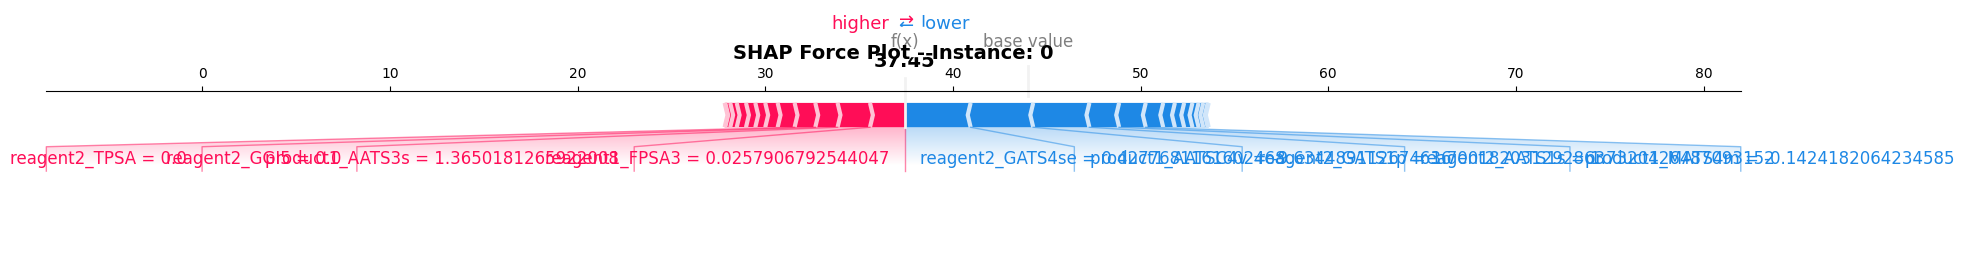

📈 Creating decision plot...


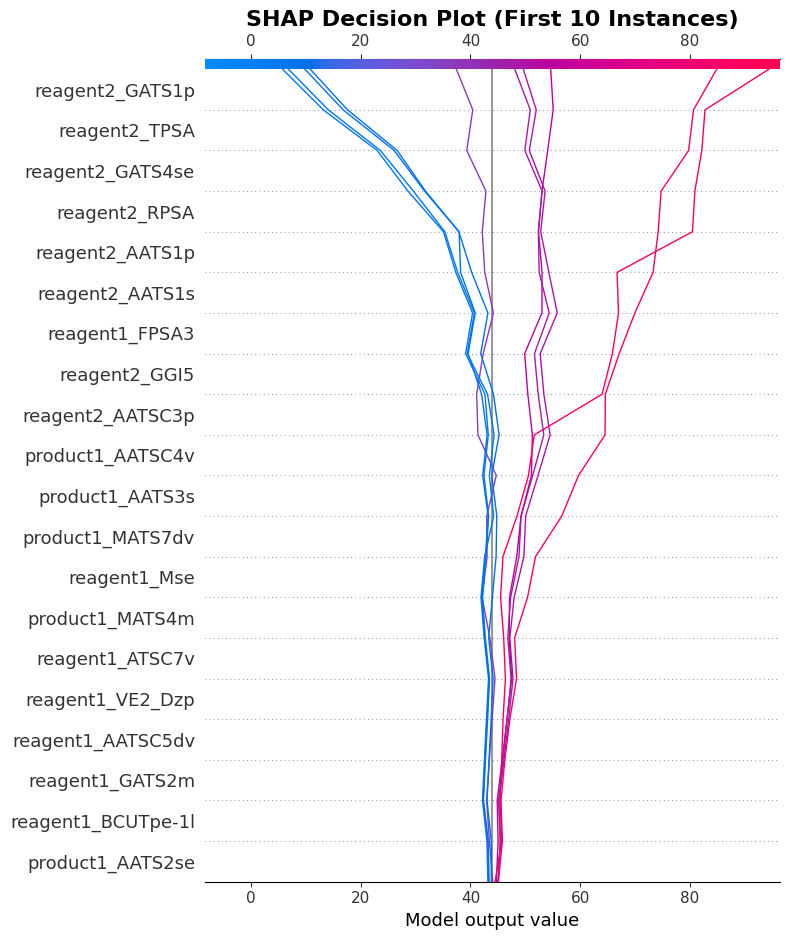

📊 Creating dependence plots for top 4 features...


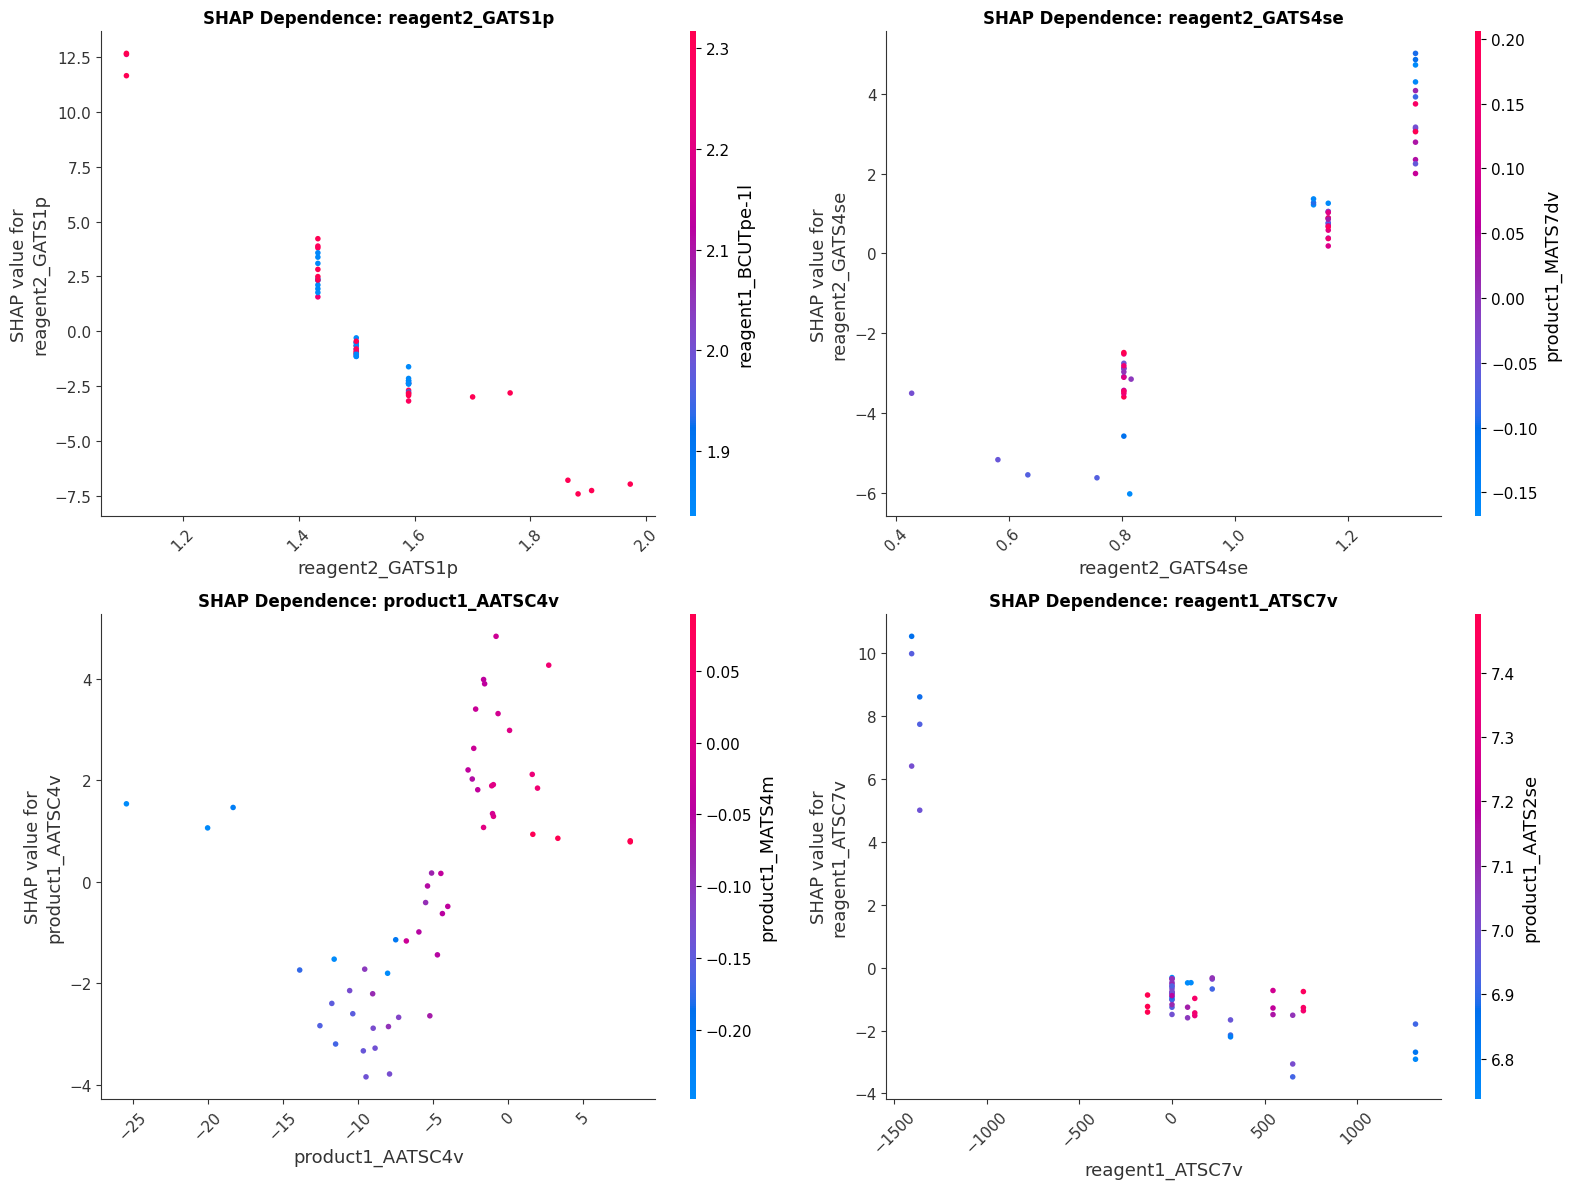


🎯 Top 15 Features by SHAP Importance:
         feature  shap_importance  shap_std
 reagent2_GATS1p           3.0177    2.8114
reagent2_GATS4se           2.6531    1.5482
product1_AATSC4v           2.0473    1.1478
 reagent1_ATSC7v           1.9631    2.3749
  reagent1_FPSA3           1.9553    1.1239
 reagent2_AATS1p           1.8744    3.1630
reagent2_AATSC3p           1.4974    2.9362
   reagent2_TPSA           1.4729    2.2763
 reagent2_AATS1s           1.4158    1.0576
product1_MATS7dv           1.3946    1.2029
   reagent2_GGI5           1.3824    0.7815
 product1_AATS3s           1.1139    0.7253
   reagent2_RPSA           0.9454    1.4934
    reagent1_Mse           0.9240    0.7600
 product1_MATS4m           0.8912    0.5764


In [ ]:
# Расширенный анализ
# aut_SHAP_b = None
_, shap_resultsB = shap_analysis_extra_trees(
    model=results_b["model"], 
    X = df_no_zeroB[features_b[:25]], 
    data = df_no_zeroB, # DataFrame с исходными данными 
    y = df_no_zeroB["b"],
    rows_to_annotate = ["reagent2_GATS1p", "reagent2_AATS1p", "reagent2_AATSC3p", "reagent2_TPSA", "reagent2_RPSA"],  # На каких строках мы хотим видеть аннотации
    threshold = 2.5 # Отсечка по значениям SHAP 

    )
# Создаем DataFrame
df_shap_b = pd.DataFrame(shap_resultsB)
df_shap_b = df_shap_b.sort_values('feature', ascending=False)

In [128]:
data.head(10)

,inp+inp=out,a,b,reagent1_nAcid,reagent1_nBase,reagent1_SpAbs_A,reagent1_SpMax_A,reagent1_SpDiam_A,reagent1_SpAD_A,reagent1_SpMAD_A,...,product1_SRW10,product1_TSRW10,product1_MW,product1_AMW,product1_WPath,product1_WPol,product1_Zagreb1,product1_Zagreb2,product1_mZagreb1,product1_mZagreb2
0,1a+2a=3aa,14,36,0.0,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,...,8.985821,45.252219,228.227328,4.855901,456.0,18.0,60.0,64.0,6.562500,4.000000
1,1a+2b=3ab,53,55,0.0,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,...,9.325899,48.607448,248.196027,5.515467,632.0,20.0,76.0,82.0,6.173611,4.041667
2,1a+2c=3ac,67,58,0.0,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,...,9.817766,55.491378,310.211677,5.965609,1143.0,31.0,104.0,118.0,6.534722,5.208333
3,1a+2d=3ad,89,96,0.0,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,...,10.167735,61.874837,372.227328,6.308938,1794.0,42.0,132.0,154.0,6.895833,6.375000
4,1a+2e=3ae,96,99,0.0,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,...,10.264687,55.243428,360.252008,5.542339,936.0,36.0,102.0,118.0,12.000000,4.562500
5,1a+2g=3ag,42,50,0.0,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,...,9.411238,55.542094,358.308719,5.192880,1600.0,24.0,98.0,100.0,9.875000,5.500000
6,1a+2h=3ah,11,11,0.0,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,...,9.579764,52.672771,334.217960,5.762379,927.0,21.0,92.0,94.0,10.437500,4.375000
7,1a+2i=3ai,9,7,0.0,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,...,10.439425,72.367679,630.293125,6.431563,3923.0,45.0,180.0,190.0,19.687500,7.375000
8,1a+2j=3aj,5,3,0.0,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,...,9.884152,57.900853,408.236751,6.003482,1392.0,27.0,114.0,118.0,12.750000,5.125000
9,1a+2k=3ak,9,9,0.0,0.0,9.517541,1.879385,3.75877,9.517541,1.189693,...,9.884152,57.900853,408.236751,6.003482,1392.0,27.0,114.0,118.0,12.750000,5.125000


In [129]:
df_shap_b.head(10)

,feature,feature_value,index,reaction_name,shap_value,abs_shap
4,reagent2_TPSA,16.285973,6,1a+2h=3ah,-9.045376,9.045376
5,reagent2_TPSA,19.896608,7,1a+2i=3ai,-9.488354,9.488354
6,reagent2_TPSA,21.400154,8,1a+2j=3aj,-9.813269,9.813269
7,reagent2_TPSA,15.524783,9,1a+2k=3ak,-9.309887,9.309887
0,reagent2_RPSA,0.034676,6,1a+2h=3ah,-6.088509,6.088509
2,reagent2_RPSA,0.039696,8,1a+2j=3aj,-6.483443,6.483443
3,reagent2_RPSA,0.038014,9,1a+2k=3ak,-6.294329,6.294329
1,reagent2_RPSA,0.024474,7,1a+2i=3ai,-5.734937,5.734937
14,reagent2_GATS1p,1.102353,4,1a+2e=3ae,11.657088,11.657088
19,reagent2_GATS1p,1.102353,12,1c+2e=3ce,12.629076,12.629076


In [130]:
df_shap_b= df_shap_b.reset_index()
df_shap_b = df_shap_b[df_shap_b.columns[1:]]

In [131]:
df_shap_b.head(6)

,feature,feature_value,index,reaction_name,shap_value,abs_shap
0,reagent2_TPSA,16.285973,6,1a+2h=3ah,-9.045376,9.045376
1,reagent2_TPSA,19.896608,7,1a+2i=3ai,-9.488354,9.488354
2,reagent2_TPSA,21.400154,8,1a+2j=3aj,-9.813269,9.813269
3,reagent2_TPSA,15.524783,9,1a+2k=3ak,-9.309887,9.309887
4,reagent2_RPSA,0.034676,6,1a+2h=3ah,-6.088509,6.088509
5,reagent2_RPSA,0.039696,8,1a+2j=3aj,-6.483443,6.483443


In [132]:
interected_d = ["reagent2_GATS1p", "reagent2_AATS1p", "reagent2_AATSC3p", "reagent2_TPSA", "reagent2_RPSA"]

In [151]:
selected_cities_b = df_shap_b[df_shap_b['feature'].isin(interected_d)]
selected = df_shap_b[(df_shap_b['feature'] == "reagent2_RPSA") & (df_shap_b['shap_value'] < 5)]

In [152]:
selected

,feature,feature_value,index,reaction_name,shap_value,abs_shap
0,reagent2_RPSA,0.034676,6,1a+2h=3ah,-6.088509,6.088509
2,reagent2_RPSA,0.039696,8,1a+2j=3aj,-6.483443,6.483443
3,reagent2_RPSA,0.038014,9,1a+2k=3ak,-6.294329,6.294329
1,reagent2_RPSA,0.024474,7,1a+2i=3ai,-5.734937,5.734937


In [ ]:
# df_no_zeroB = df_no_zeroB[df_no_zeroB.columns[2:]]

In [ ]:
# df_no_zeroB.to_csv('../data/df_no_zeroB.csv')

In [ ]:
# data = data[data.columns[1:]]

In [ ]:
# data.to_csv('../data/data_a.csv')

# SHAP для a

SHAP ANALYSIS FOR EXTRA TREES REGRESSION
Using all 69 instances for SHAP analysis
Calculating SHAP values...
SHAP values shape: (69, 26)

📈 Creating summary plot with index annotations...
reagent1_C2SP2
reagent2_MATS1se

📊 ТОЧКИ С ВЫСОКИМ ВЛИЯНИЕМ (|SHAP| > 2.50)
         feature  feature_value  index reaction_name  shap_value  abs_shap
reagent2_MATS1se      -0.326110     16     1i+2b=3ib   -6.303076  6.303076
reagent2_MATS1se      -0.326110     43     1p+2b=3pb   -4.498230  4.498230
reagent2_MATS1se      -0.100724     41     1o+2d=3od    2.864601  2.864601
reagent2_MATS1se      -0.326110     39     1o+2b=3ob   -4.258810  4.258810
reagent2_MATS1se      -0.024336     38     1n+2e=3ne    4.221554  4.221554
reagent2_MATS1se      -0.100724     37     1n+2d=3nd    2.717677  2.717677
reagent2_MATS1se      -0.326110     35     1n+2b=3nb   -4.322955  4.322955
reagent2_MATS1se      -0.024336     34     1m+2e=3me    4.214276  4.214276
reagent2_MATS1se      -0.100724     33     1m+2d=3md    3.402

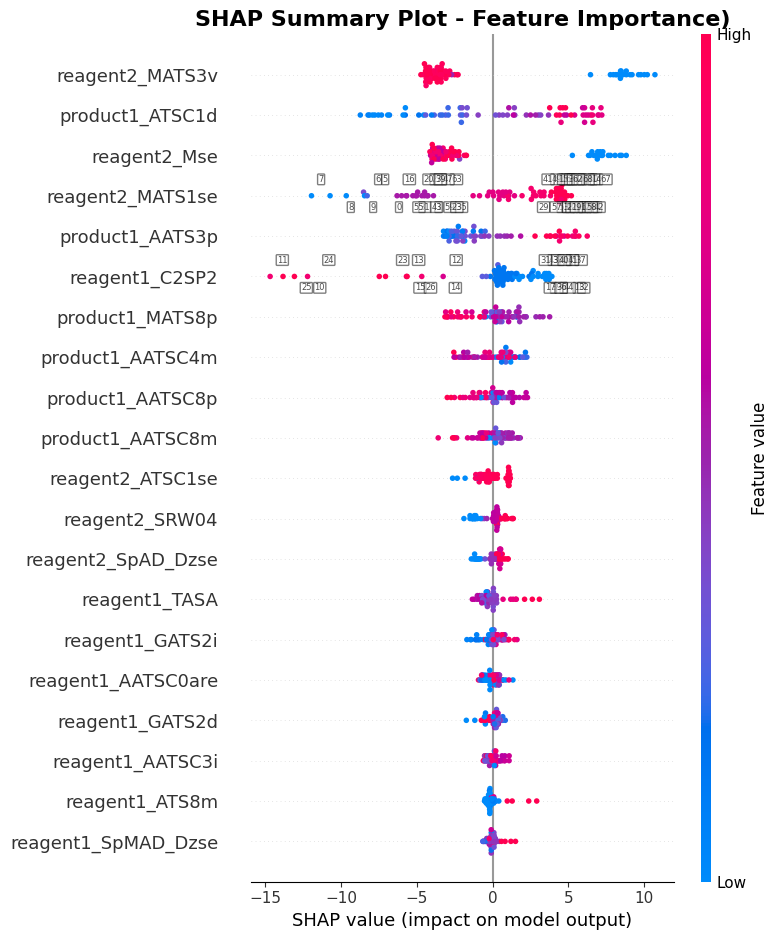

📊 Creating feature importance plot...


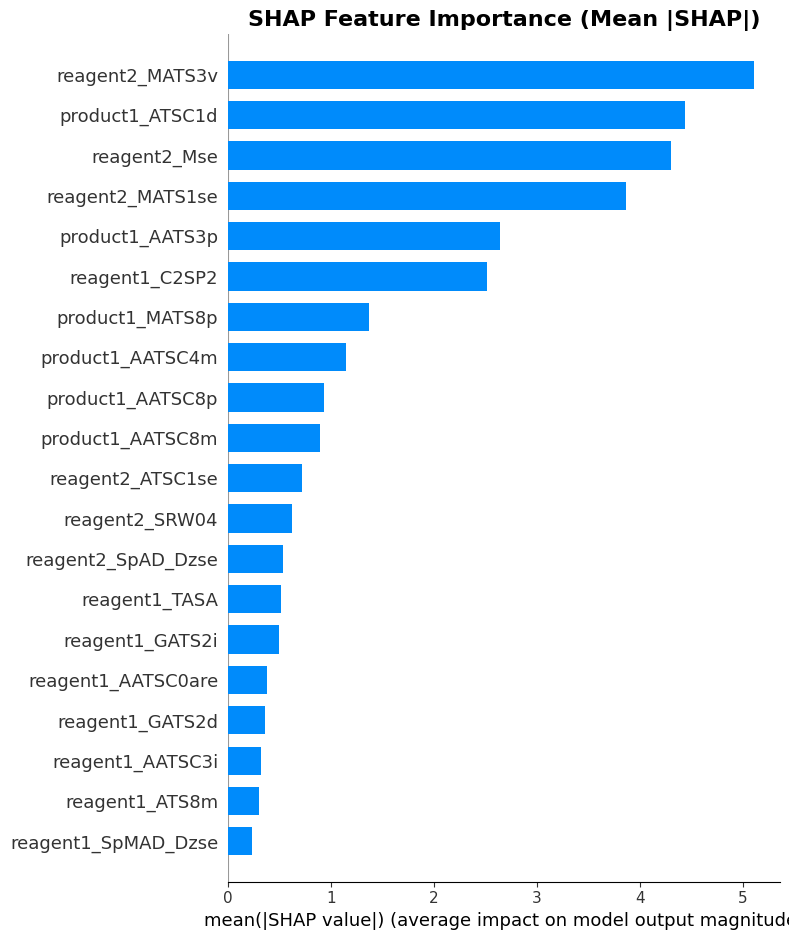

🐝 Creating beeswarm plot...


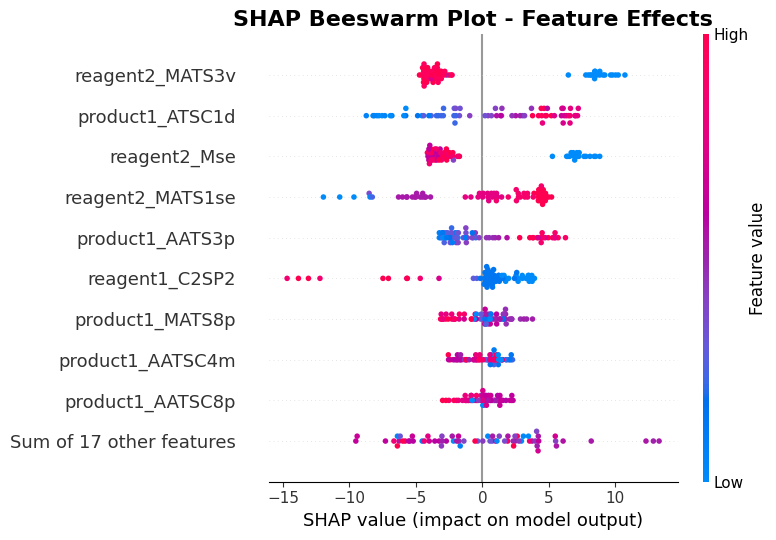

🌊 Creating waterfall plot for first instance...


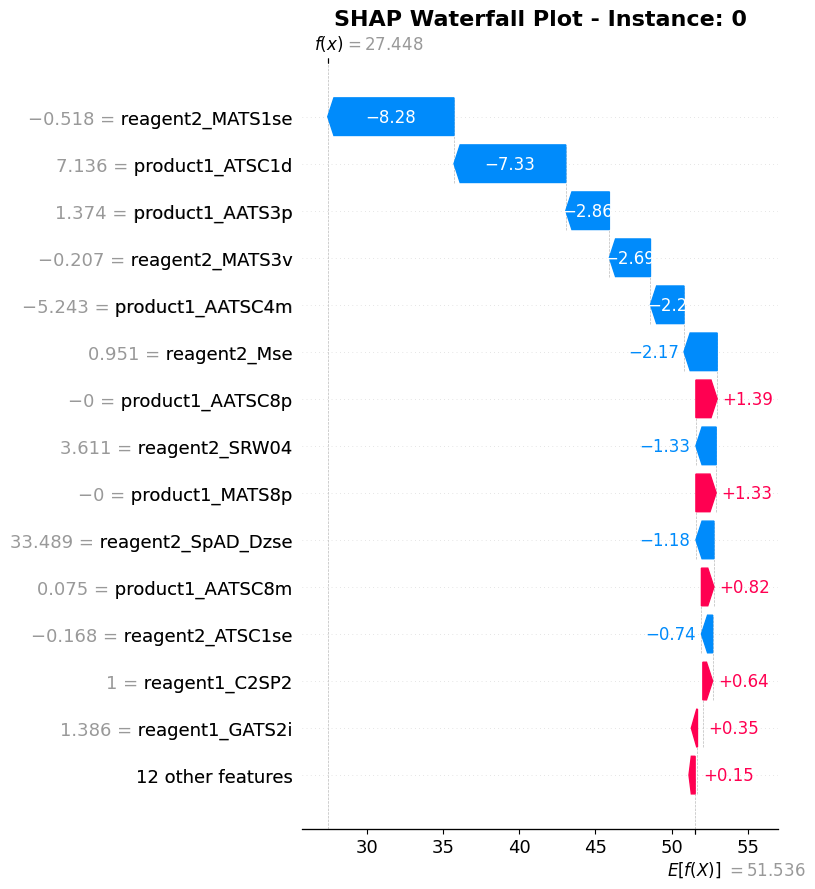

⚡ Creating force plot...


<Figure size 1400x400 with 0 Axes>

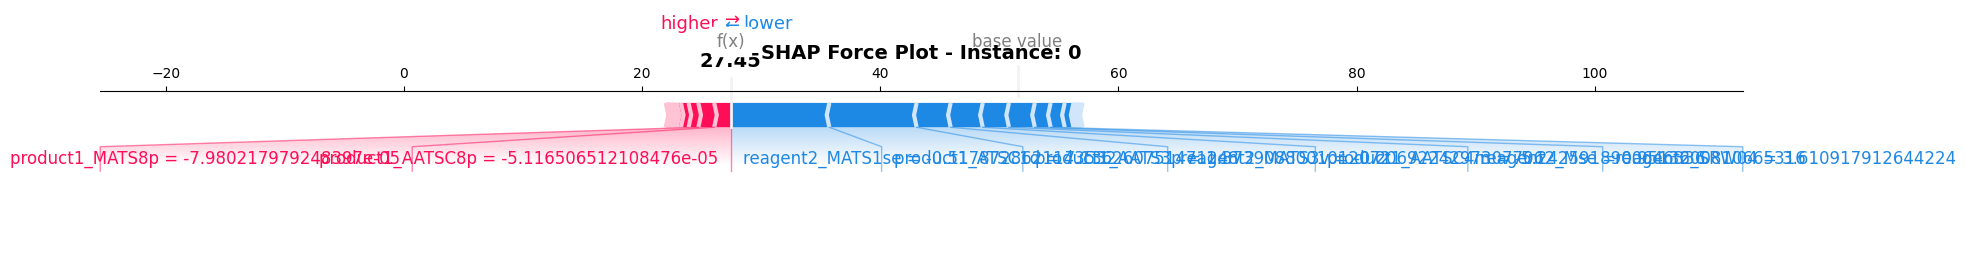

📈 Creating decision plot...


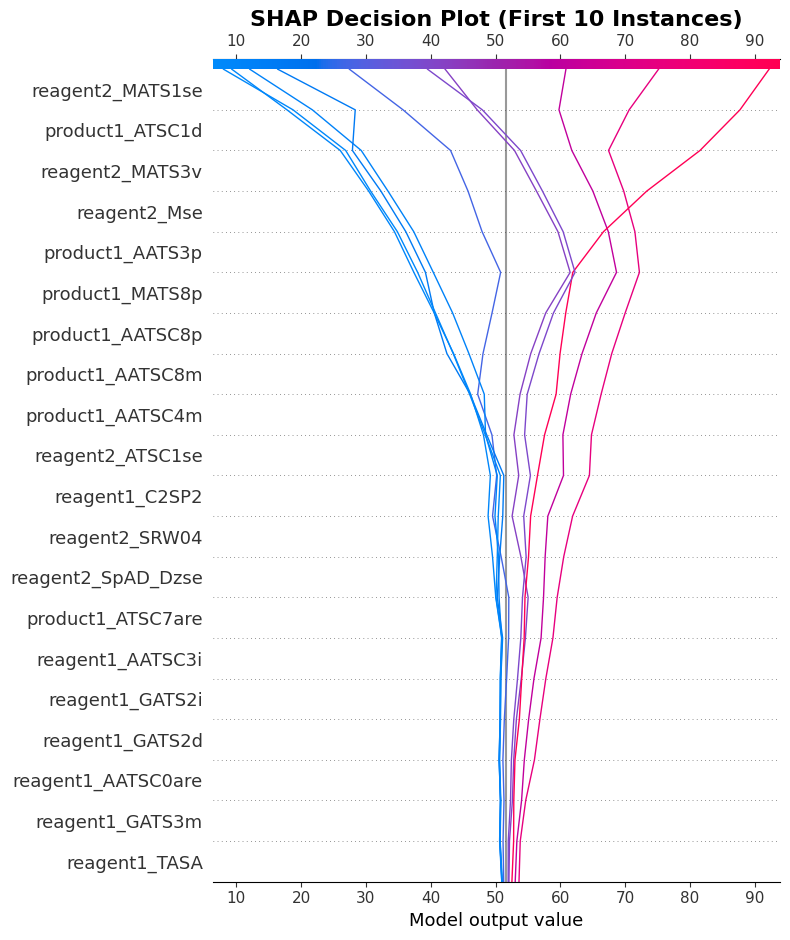

📊 Creating dependence plots for top 4 features...


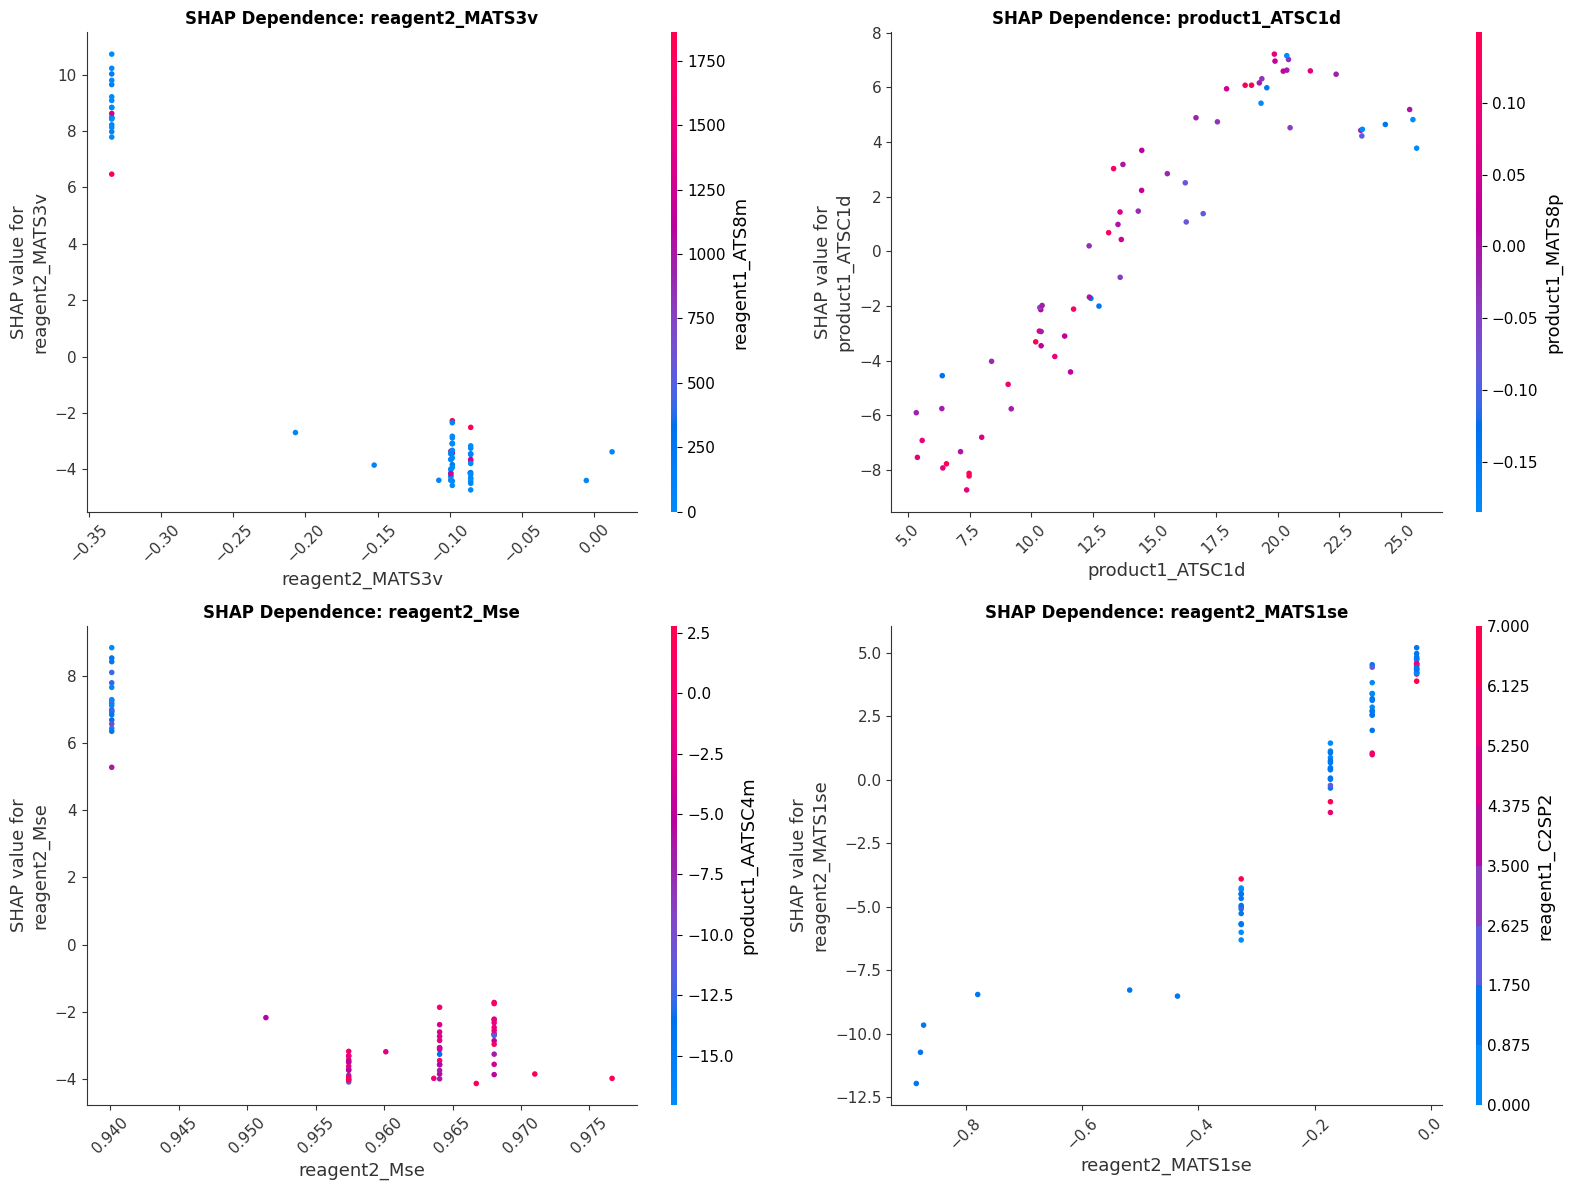


🎯 Top 15 Features by SHAP Importance:
           feature  shap_importance  shap_std
   reagent2_MATS3v           5.1054    2.3942
   product1_ATSC1d           4.4402    2.2494
      reagent2_Mse           4.2996    1.9350
  reagent2_MATS1se           3.8663    2.4894
   product1_AATS3p           2.6386    1.4654
    reagent1_C2SP2           2.5130    3.1874
   product1_MATS8p           1.3652    1.0021
  product1_AATSC4m           1.1485    0.6638
  product1_AATSC8p           0.9336    0.7331
  product1_AATSC8m           0.8931    0.6971
  reagent2_ATSC1se           0.7181    0.5029
    reagent2_SRW04           0.6232    0.4515
reagent2_SpAD_Dzse           0.5378    0.3457
     reagent1_TASA           0.5151    0.5947
   reagent1_GATS2i           0.4981    0.4395


In [158]:
# Расширенный анализ
interested_a = ["reagent2_MATS1se", "reagent1_C2SP2"]
_, shap_resultsA = shap_analysis_extra_trees(
    model=results_a["model"],
    X = data[features_a[:26]], 
    y = data["a"], 
    data = data,
    rows_to_annotate = interested_a,
    threshold = 2.5
    )
# Создаем DataFrame
df_shap_a = pd.DataFrame(shap_resultsA)
df_shap_a = df_shap_a.sort_values('feature', ascending=False)

In [159]:
df_shap_a = df_shap_a.reset_index()


In [160]:
df_shap_a = df_shap_a[df_shap_a.columns[1:]]

In [161]:
df_shap_a.head(10)

,feature,feature_value,index,reaction_name,shap_value,abs_shap
0,reagent2_MATS1se,-0.326110,16,1i+2b=3ib,-6.303076,6.303076
1,reagent2_MATS1se,-0.326110,43,1p+2b=3pb,-4.498230,4.498230
2,reagent2_MATS1se,-0.100724,41,1o+2d=3od,2.864601,2.864601
3,reagent2_MATS1se,-0.326110,39,1o+2b=3ob,-4.258810,4.258810
4,reagent2_MATS1se,-0.024336,38,1n+2e=3ne,4.221554,4.221554
5,reagent2_MATS1se,-0.100724,37,1n+2d=3nd,2.717677,2.717677
6,reagent2_MATS1se,-0.326110,35,1n+2b=3nb,-4.322955,4.322955
7,reagent2_MATS1se,-0.024336,34,1m+2e=3me,4.214276,4.214276
8,reagent2_MATS1se,-0.100724,33,1m+2d=3md,3.402079,3.402079
9,reagent2_MATS1se,-0.326110,31,1m+2b=3mb,-6.002085,6.002085


In [95]:
interected_a = ["reagent2_MATS1se", "reagent1_C2SP2"]

In [168]:
selected_cities_a = df_shap_a[df_shap_a['feature'].isin(interected_d)]
selected = df_shap_a[(df_shap_a['feature'] == "reagent1_C2SP2") & (df_shap_a['shap_value'] < -2.5)]

In [169]:
selected

,feature,feature_value,index,reaction_name,shap_value,abs_shap
51,reagent1_C2SP2,7.0,15,1f+2e=3fe,-7.064814,7.064814
52,reagent1_C2SP2,7.0,24,1k+2c=3kc,-13.081511,13.081511
53,reagent1_C2SP2,7.0,23,1k+2d=3kb,-7.476149,7.476149
56,reagent1_C2SP2,6.0,10,1c+2c=3cc,-12.213505,12.213505
57,reagent1_C2SP2,5.0,14,1e+2e=3ee,-3.259612,3.259612
58,reagent1_C2SP2,6.0,13,1d+2e=3de,-5.686854,5.686854
59,reagent1_C2SP2,6.0,12,1c+2e=3ce,-4.670725,4.670725
60,reagent1_C2SP2,6.0,11,1c+2d=3cd,-14.684383,14.684383
61,reagent1_C2SP2,7.0,26,1k+2e=3ke,-5.638462,5.638462
62,reagent1_C2SP2,7.0,25,1k+2d=3kd,-13.832726,13.832726


In [170]:
selected.sort_values('shap_value', ascending=False)

,feature,feature_value,index,reaction_name,shap_value,abs_shap
57,reagent1_C2SP2,5.0,14,1e+2e=3ee,-3.259612,3.259612
59,reagent1_C2SP2,6.0,12,1c+2e=3ce,-4.670725,4.670725
61,reagent1_C2SP2,7.0,26,1k+2e=3ke,-5.638462,5.638462
58,reagent1_C2SP2,6.0,13,1d+2e=3de,-5.686854,5.686854
51,reagent1_C2SP2,7.0,15,1f+2e=3fe,-7.064814,7.064814
53,reagent1_C2SP2,7.0,23,1k+2d=3kb,-7.476149,7.476149
56,reagent1_C2SP2,6.0,10,1c+2c=3cc,-12.213505,12.213505
52,reagent1_C2SP2,7.0,24,1k+2c=3kc,-13.081511,13.081511
62,reagent1_C2SP2,7.0,25,1k+2d=3kd,-13.832726,13.832726
60,reagent1_C2SP2,6.0,11,1c+2d=3cd,-14.684383,14.684383


# SHAP на b для a

In [177]:
interected_ba = interected_a + interected_d

SHAP ANALYSIS FOR EXTRA TREES REGRESSION
Using all 69 instances for SHAP analysis
Calculating SHAP values...
SHAP values shape: (69, 25)

📈 Creating summary plot with index annotations...
reagent2_RPSA
reagent2_TPSA
reagent2_GATS1p
reagent2_AATSC3p
reagent2_AATS1p

📊 ТОЧКИ С ВЫСОКИМ ВЛИЯНИЕМ (|SHAP| > 5.00)
         feature  feature_value  index reaction_name  shap_value  abs_shap
 reagent2_GATS1p       1.700182      0     1a+2a=3aa   -6.973594  6.973594
 reagent2_GATS1p       1.589604     31     1m+2b=3mb   -5.148707  5.148707
 reagent2_GATS1p       1.102353     68     1w+2e=3we    8.287828  8.287828
 reagent2_GATS1p       1.102353     67     1v+2e=3ve    9.889237  9.889237
 reagent2_GATS1p       1.102353     66     1u+2e=3ue    7.708700  7.708700
 reagent2_GATS1p       1.102353     62     1t+2e=3te    8.714187  8.714187
 reagent2_GATS1p       1.589604     59     1t+2b=3tb   -5.046806  5.046806
 reagent2_GATS1p       1.102353     58     1s+2e=3se    9.836797  9.836797
 reagent2_GATS1p

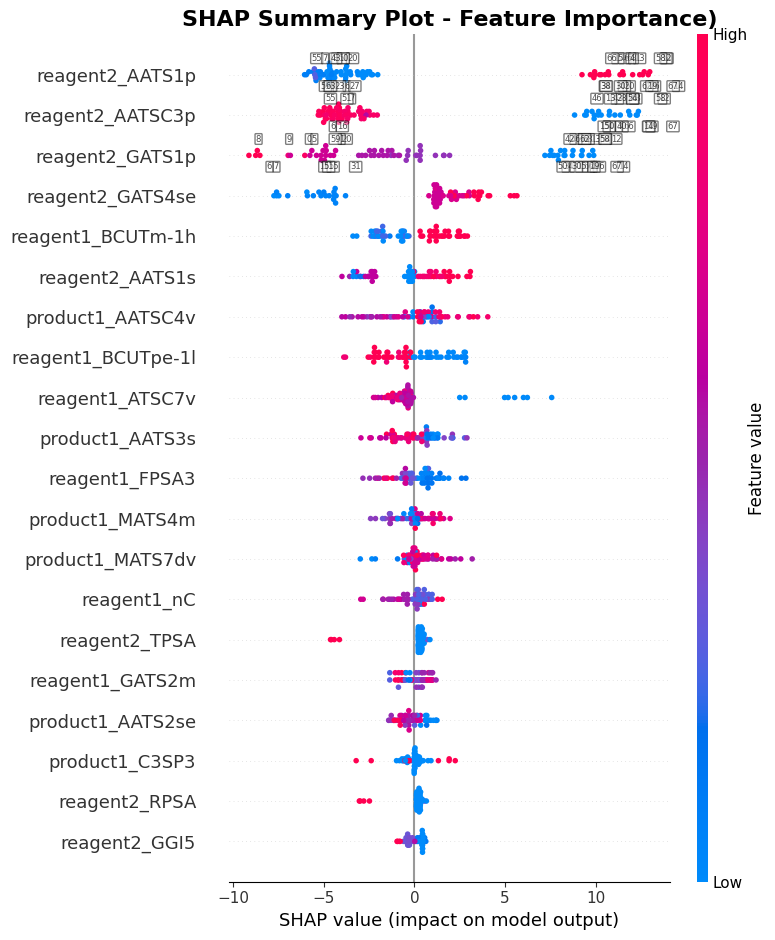

📊 Creating feature importance plot...


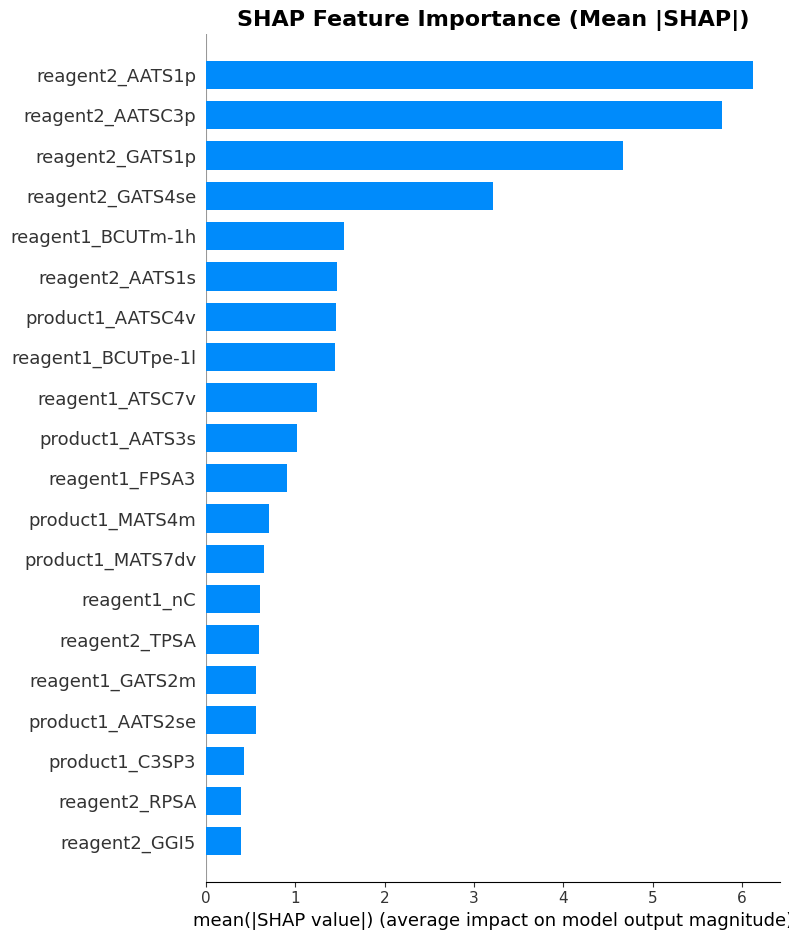

🐝 Creating beeswarm plot...


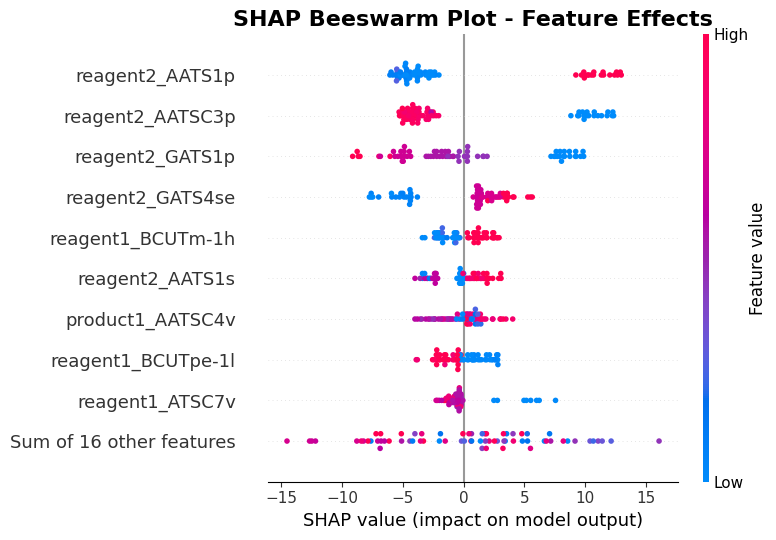

🌊 Creating waterfall plot for first instance...


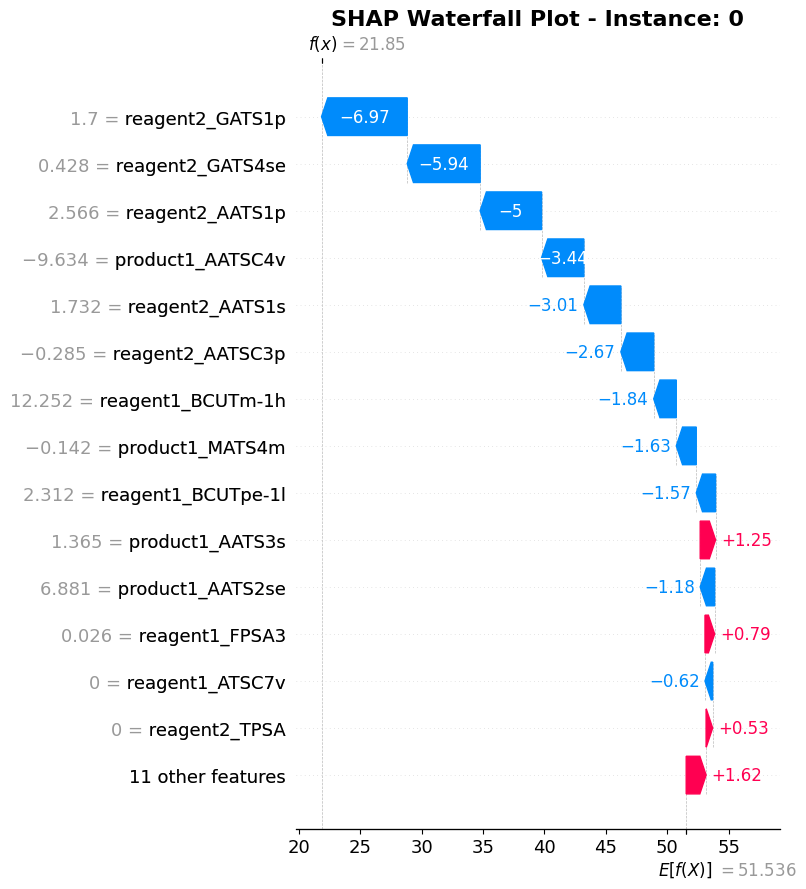

⚡ Creating force plot...


<Figure size 1400x400 with 0 Axes>

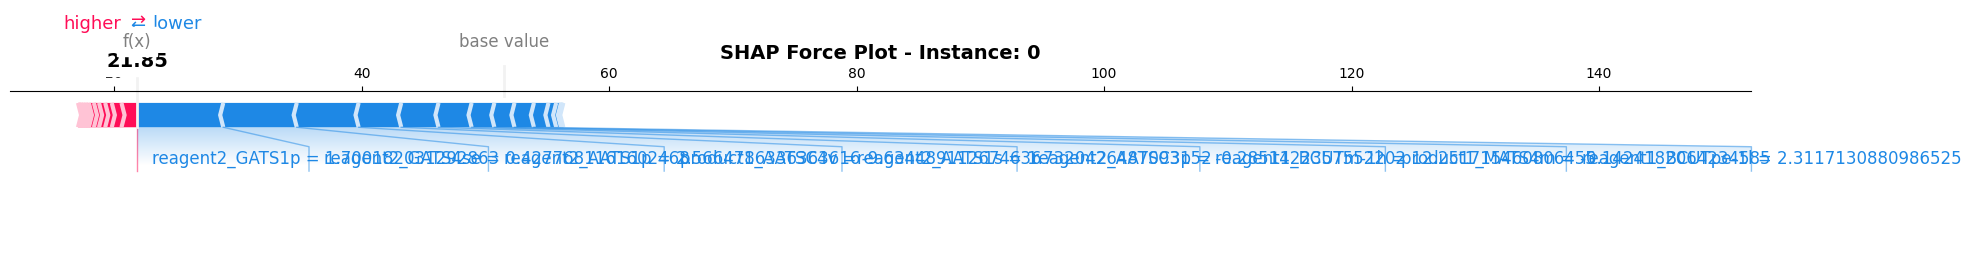

📈 Creating decision plot...


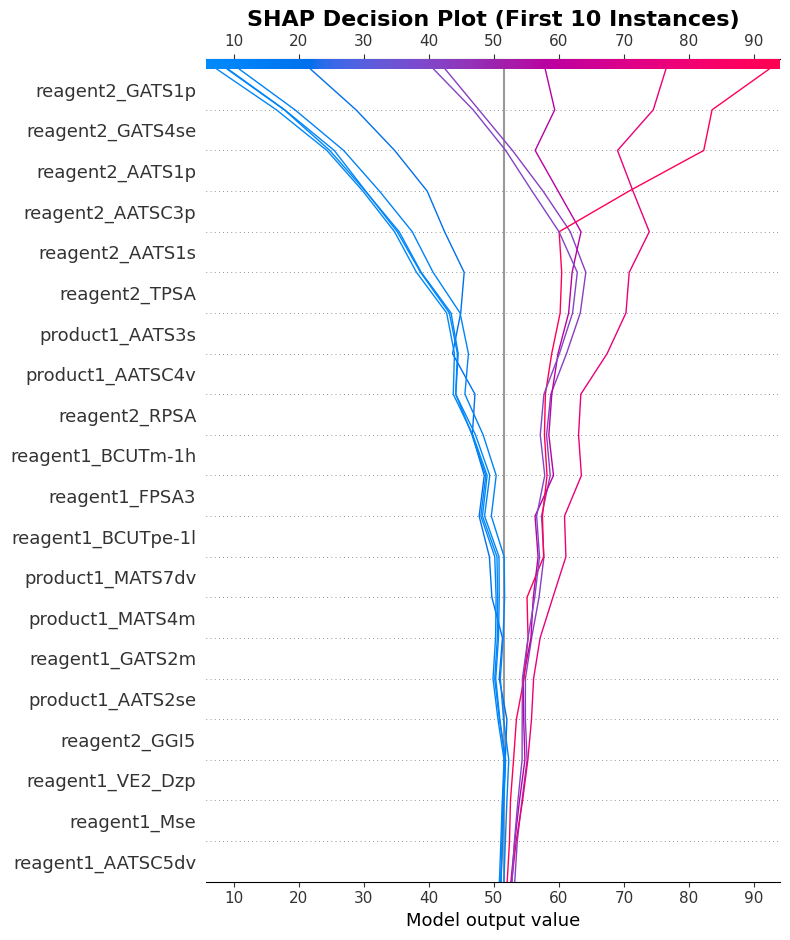

📊 Creating dependence plots for top 4 features...


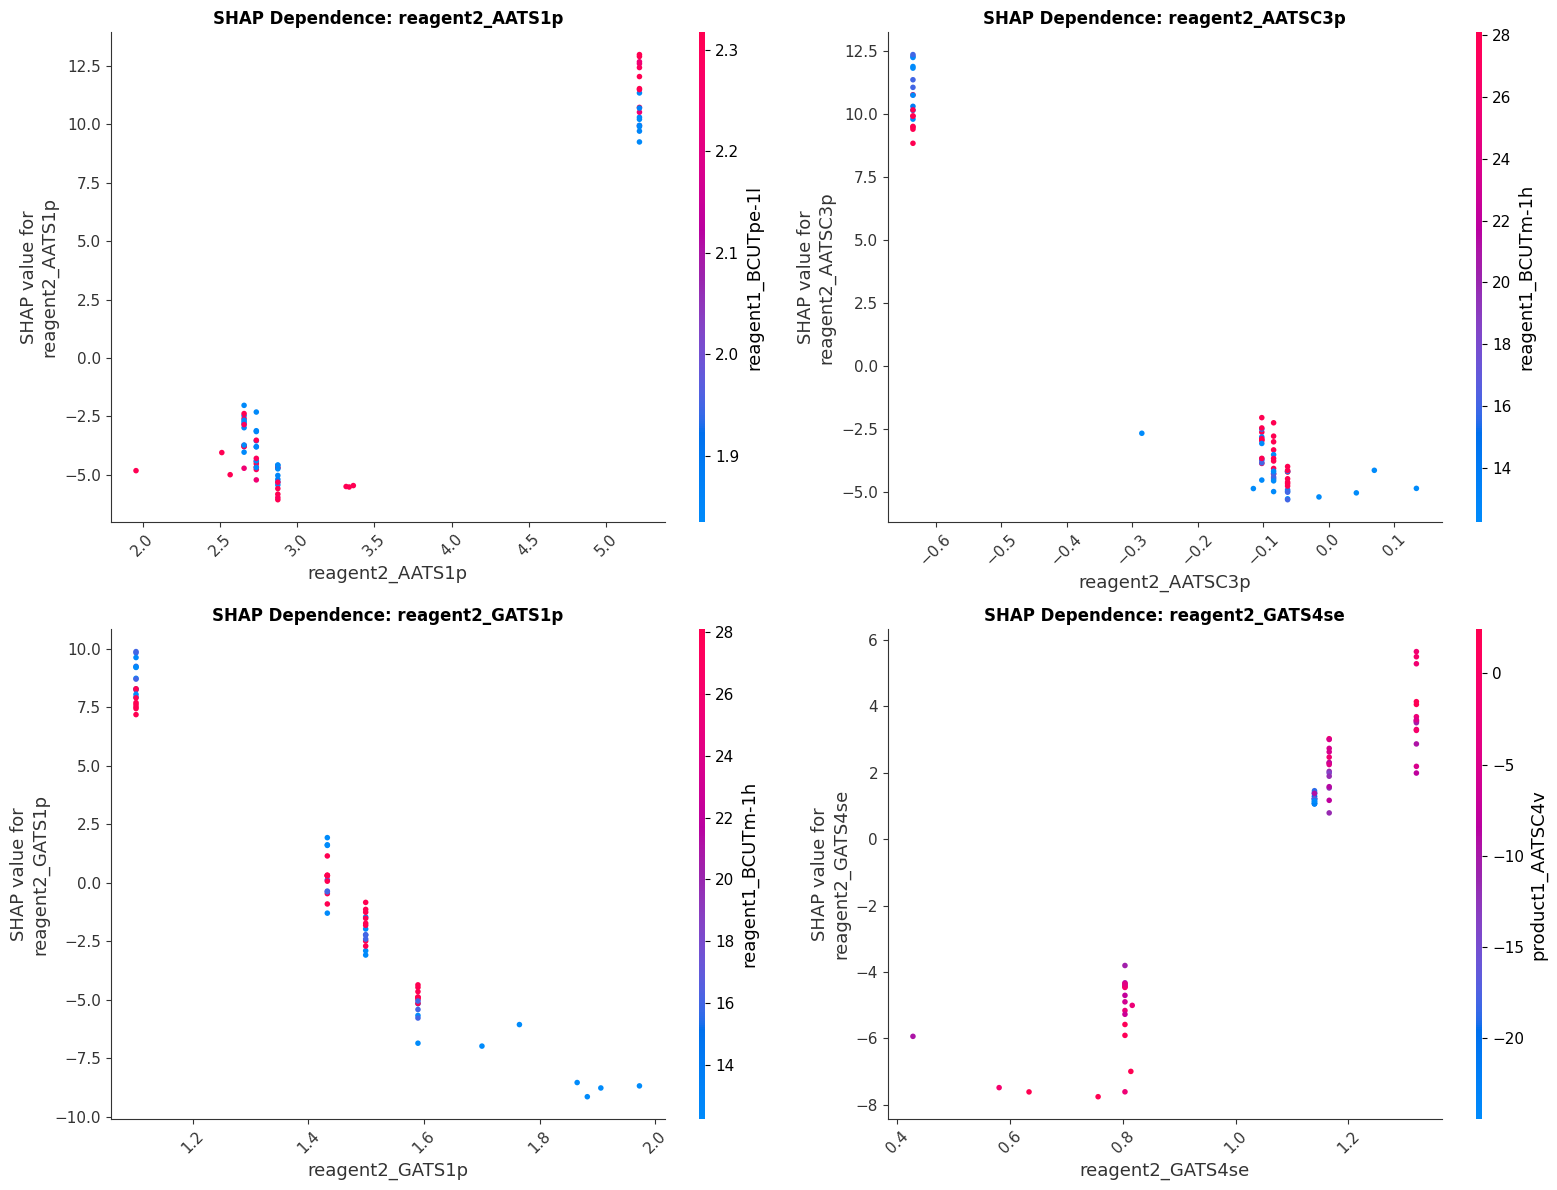


🎯 Top 15 Features by SHAP Importance:
           feature  shap_importance  shap_std
   reagent2_AATS1p           6.1195    3.2693
  reagent2_AATSC3p           5.7806    3.1310
   reagent2_GATS1p           4.6657    3.2323
  reagent2_GATS4se           3.2102    1.9279
 reagent1_BCUTm-1h           1.5444    0.7737
   reagent2_AATS1s           1.4643    1.1386
  product1_AATSC4v           1.4570    1.0944
reagent1_BCUTpe-1l           1.4407    0.9299
   reagent1_ATSC7v           1.2389    1.5742
   product1_AATS3s           1.0235    0.7005
    reagent1_FPSA3           0.9066    0.6695
   product1_MATS4m           0.7097    0.6015
  product1_MATS7dv           0.6503    0.7545
       reagent1_nC           0.6066    0.5744
     reagent2_TPSA           0.5960    0.9648


In [176]:
# Расширенный анализ
_, shap_resultsA_b = shap_analysis_extra_trees(
    model=resultsA_b["model"],
    X = data[features_b[:25]], 
    y = data["a"], 
    data = data,
    rows_to_annotate = interected_a + interected_d,
    threshold=5
    )
# Создаем DataFrame
df_shap_ab = pd.DataFrame(shap_resultsA_b)
df_shap_ab = df_shap_ab.sort_values('feature', ascending=False)

In [178]:
df_shap_ab = df_shap_ab.reset_index()

In [179]:
df_shap_ab = df_shap_ab[df_shap_ab.columns[1:]]

In [181]:
df_shap_ab.head(5)

,feature,feature_value,index,reaction_name,shap_value,abs_shap
0,reagent2_GATS1p,1.700182,0,1a+2a=3aa,-6.973594,6.973594
1,reagent2_GATS1p,1.589604,31,1m+2b=3mb,-5.148707,5.148707
2,reagent2_GATS1p,1.102353,68,1w+2e=3we,8.287828,8.287828
3,reagent2_GATS1p,1.102353,67,1v+2e=3ve,9.889237,9.889237
4,reagent2_GATS1p,1.102353,66,1u+2e=3ue,7.708700,7.708700


In [182]:
interected_ba

['reagent2_MATS1se',
 'reagent1_C2SP2',
 'reagent2_GATS1p',
 'reagent2_AATS1p',
 'reagent2_AATSC3p',
 'reagent2_TPSA',
 'reagent2_RPSA']

In [183]:
selected_cities_b = df_shap_ab[df_shap_ab['feature'].isin(interected_ba)]
selected = df_shap_ab[(df_shap_ab['feature'] == "reagent2_GATS1p") & (df_shap_ab['shap_value'] < -7)]

In [184]:
selected

,feature,feature_value,index,reaction_name,shap_value,abs_shap
21,reagent2_GATS1p,1.864721,6,1a+2h=3ah,-8.531346,8.531346
22,reagent2_GATS1p,1.905650,7,1a+2i=3ai,-8.763495,8.763495
23,reagent2_GATS1p,1.882260,8,1a+2j=3aj,-9.137238,9.137238
24,reagent2_GATS1p,1.972372,9,1a+2k=3ak,-8.674643,8.674643


In [86]:
print("Размер данных для предсказания:", data[features_a[:26]].shape)
print("Размер данных обучения:", results_a["X_train"].shape)

Размер данных для предсказания: (69, 26)
Размер данных обучения: (69, 26)


In [89]:
print("Размер данных для предсказания:", df_no_zeroB[features_b[:25]].shape)
print("Размер данных обучения:", results_b["X_train"].shape)

Размер данных для предсказания: (53, 25)
Размер данных обучения: (53, 25)


In [91]:
def check_feature_order(model, data, features):
    """Проверяет порядок признаков в модели и данных"""
    
    print("=" * 60)
    print("ПРОВЕРКА ПОРЯДКА ПРИЗНАКОВ")
    print("=" * 60)
    
    # 1. Проверяем, хранит ли модель имена признаков
    if hasattr(model, 'feature_names_in_'):
        model_features = list(model.feature_names_in_)
        print(f"✅ Модель хранит имена признаков ({len(model_features)} шт.)")
        print("Первые 5 признаков модели:", model_features[:5])
    else:
        print("❌ Модель НЕ хранит имена признаков")
        model_features = None
    
    # 2. Порядок признаков в данных
    data_features = list(data[features].columns)
    print(f"Признаки в данных ({len(data_features)} шт.):", data_features[:5])
    
    # 3. Сравнение порядков
    if model_features and data_features:
        if model_features == data_features:
            print("✅ Порядок признаков СОВПАДАЕТ")
        else:
            print("❌ Порядок признаков РАЗЛИЧАЕТСЯ!")
            print("Различия в первых 5 позициях:")
            for i in range(min(5, len(model_features), len(data_features))):
                status = "==" if model_features[i] == data_features[i] else "!="
                print(f"  Позиция {i}: модель '{model_features[i]}' {status} данные '{data_features[i]}'")
    
    return model_features, data_features

# Проверьте перед предсказанием
model_features, data_features = check_feature_order(
    results_b["model"], df_no_zeroB, features_b[:25]
)

ПРОВЕРКА ПОРЯДКА ПРИЗНАКОВ
✅ Модель хранит имена признаков (25 шт.)
Первые 5 признаков модели: ['reagent1_nC', 'reagent1_ATSC7v', 'reagent1_AATSC5dv', 'reagent1_AATSC0i', 'reagent1_GATS2m']
Признаки в данных (25 шт.): ['reagent1_nC', 'reagent1_ATSC7v', 'reagent1_AATSC5dv', 'reagent1_AATSC0i', 'reagent1_GATS2m']
✅ Порядок признаков СОВПАДАЕТ


In [92]:
def safe_predict(model, data, features, model_name=""):
    """
    Безопасное предсказание с проверкой порядка признаков
    """
    print(f"🔍 Предсказание для {model_name}")
    
    # 1. Получаем признаки, которые ожидает модель
    if hasattr(model, 'feature_names_in_'):
        expected_features = list(model.feature_names_in_)
    else:
        # Если модель не хранит имена, используем переданные
        expected_features = features
        print("⚠️ Модель не хранит имена признаков, используем переданный список")
    
    print(f"Модель ожидает {len(expected_features)} признаков")
    
    # 2. Проверяем наличие всех признаков
    missing_features = [f for f in expected_features if f not in data.columns]
    if missing_features:
        print(f"❌ Отсутствуют признаки: {missing_features}")
        return None
    
    # 3. Упорядочиваем данные в ТОЧНОМ порядке модели
    ordered_data = data[expected_features]
    
    print(f"✅ Данные подготовлены: {ordered_data.shape}")
    print("Первые 5 признаков в порядке модели:", list(ordered_data.columns[:5]))
    
    # 4. Делаем предсказание
    predictions = model.predict(ordered_data)
    
    return predictions

In [93]:
# Тест: намеренно меняем порядок признаков
def test_feature_order_issue():
    """Тестирует проблему с порядком признаков"""
    
    # Обучаем модель
    results = extra_trees_loo_analysis_castom(
        data[features_a[:26]], data["a"], test_size=10, random_state=42
    )
    
    # 1. Предсказание с правильным порядком
    correct_predictions = safe_predict(
        results["model"], data[features_a[:26]], features_a[:26]
    )
    
    # 2. Предсказание с перемешанным порядком
    shuffled_features = features_a[:26].copy()
    random.shuffle(shuffled_features)
    
    wrong_predictions = safe_predict(
        results["model"], data[shuffled_features], shuffled_features
    )
    
    # Сравниваем результаты
    if correct_predictions is not None and wrong_predictions is not None:
        differences = abs(correct_predictions - wrong_predictions)
        print(f"📊 Максимальная разница из-за порядка: {differences.max():.6f}")
        print(f"📊 Средняя разница: {differences.mean():.6f}")
        
        if differences.max() > 0.001:
            print("❌ Порядок признаков ВЛИЯЕТ на предсказания!")

test_feature_order_issue()

ПОЛНЫЙ АНАЛИЗ EXTRA TREES С LEAVE-ONE-OUT
Размер тренировочных данных: (59, 26)
Размер новых данных (модель никогда не видела): (10, 26)
Новые образцы для предсказания: [22, 0, 47, 4, 53, 18, 10, 33, 44, 12]

LEAVE-ONE-OUT КРОСС-ВАЛИДАЦИЯ

ФИНАЛЬНОЕ ОБУЧЕНИЕ МОДЕЛИ

📊 РЕЗУЛЬТАТЫ:
Метрики на тренировочных данных:
  R²: 0.9708, MSE: 23.4408, MAE: 3.5167

Метрики Leave-One-Out:
  R²: 0.7213, MSE: 223.7585, MAE: 11.8119
  LOO Score (mean neg_MSE): -223.7585 ± 316.2371

Метрики на НОВЫХ данных (модель никогда не видела):
  R²: 0.5662, MSE: 382.3139, MAE: 17.0111
🔍 Предсказание для 
Модель ожидает 26 признаков
✅ Данные подготовлены: (69, 26)
Первые 5 признаков в порядке модели: ['reagent1_ATS2Z', 'reagent1_ATS1m', 'reagent1_ATS8m', 'reagent1_AATSC0are', 'reagent1_AATSC3i']
🔍 Предсказание для 
Модель ожидает 26 признаков
✅ Данные подготовлены: (69, 26)
Первые 5 признаков в порядке модели: ['reagent1_ATS2Z', 'reagent1_ATS1m', 'reagent1_ATS8m', 'reagent1_AATSC0are', 'reagent1_AATSC3i']
📊 Максим